In [55]:
from astropy.table import Table
import pandas as pd
import os
import numpy as np
import re
from pathlib import Path

from collections import Counter, defaultdict
import h5py

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rc
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True

In [32]:
base = '/pscratch/sd/v/vtorresg/umap_analysis/sum'

In [33]:
files = os.listdir(base)
len(files)

14199

In [42]:
dfs_ = []
for file in files:
    dfs_.append(pd.read_csv(f'{base}/{file}'))

dfs = pd.concat(dfs_, ignore_index=True)

In [43]:
dfs.head()

,TARGETID,TILE,NIGHT,SPECTYPE,SUBTYPES,CATEGORY,ZWARN,R
0,39627697512518406,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,4,3
1,39627703543927450,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,0,4
2,39627709575332142,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,0,4
3,39627709600501233,3157,20220408,GALAXY,"['MAIN:LRG', 'MAIN:LRG_SOUTH']",LRG,0,6
4,39627709600500439,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,0,6


In [44]:
np.unique(dfs['ZWARN'])

array([  0,   1,   4,   5, 512, 515, 516])

In [45]:
np.unique(dfs['TILE']).shape

(14199,)

In [46]:
np.unique(dfs['SPECTYPE'])

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [47]:
dfs.groupby(['SPECTYPE'])

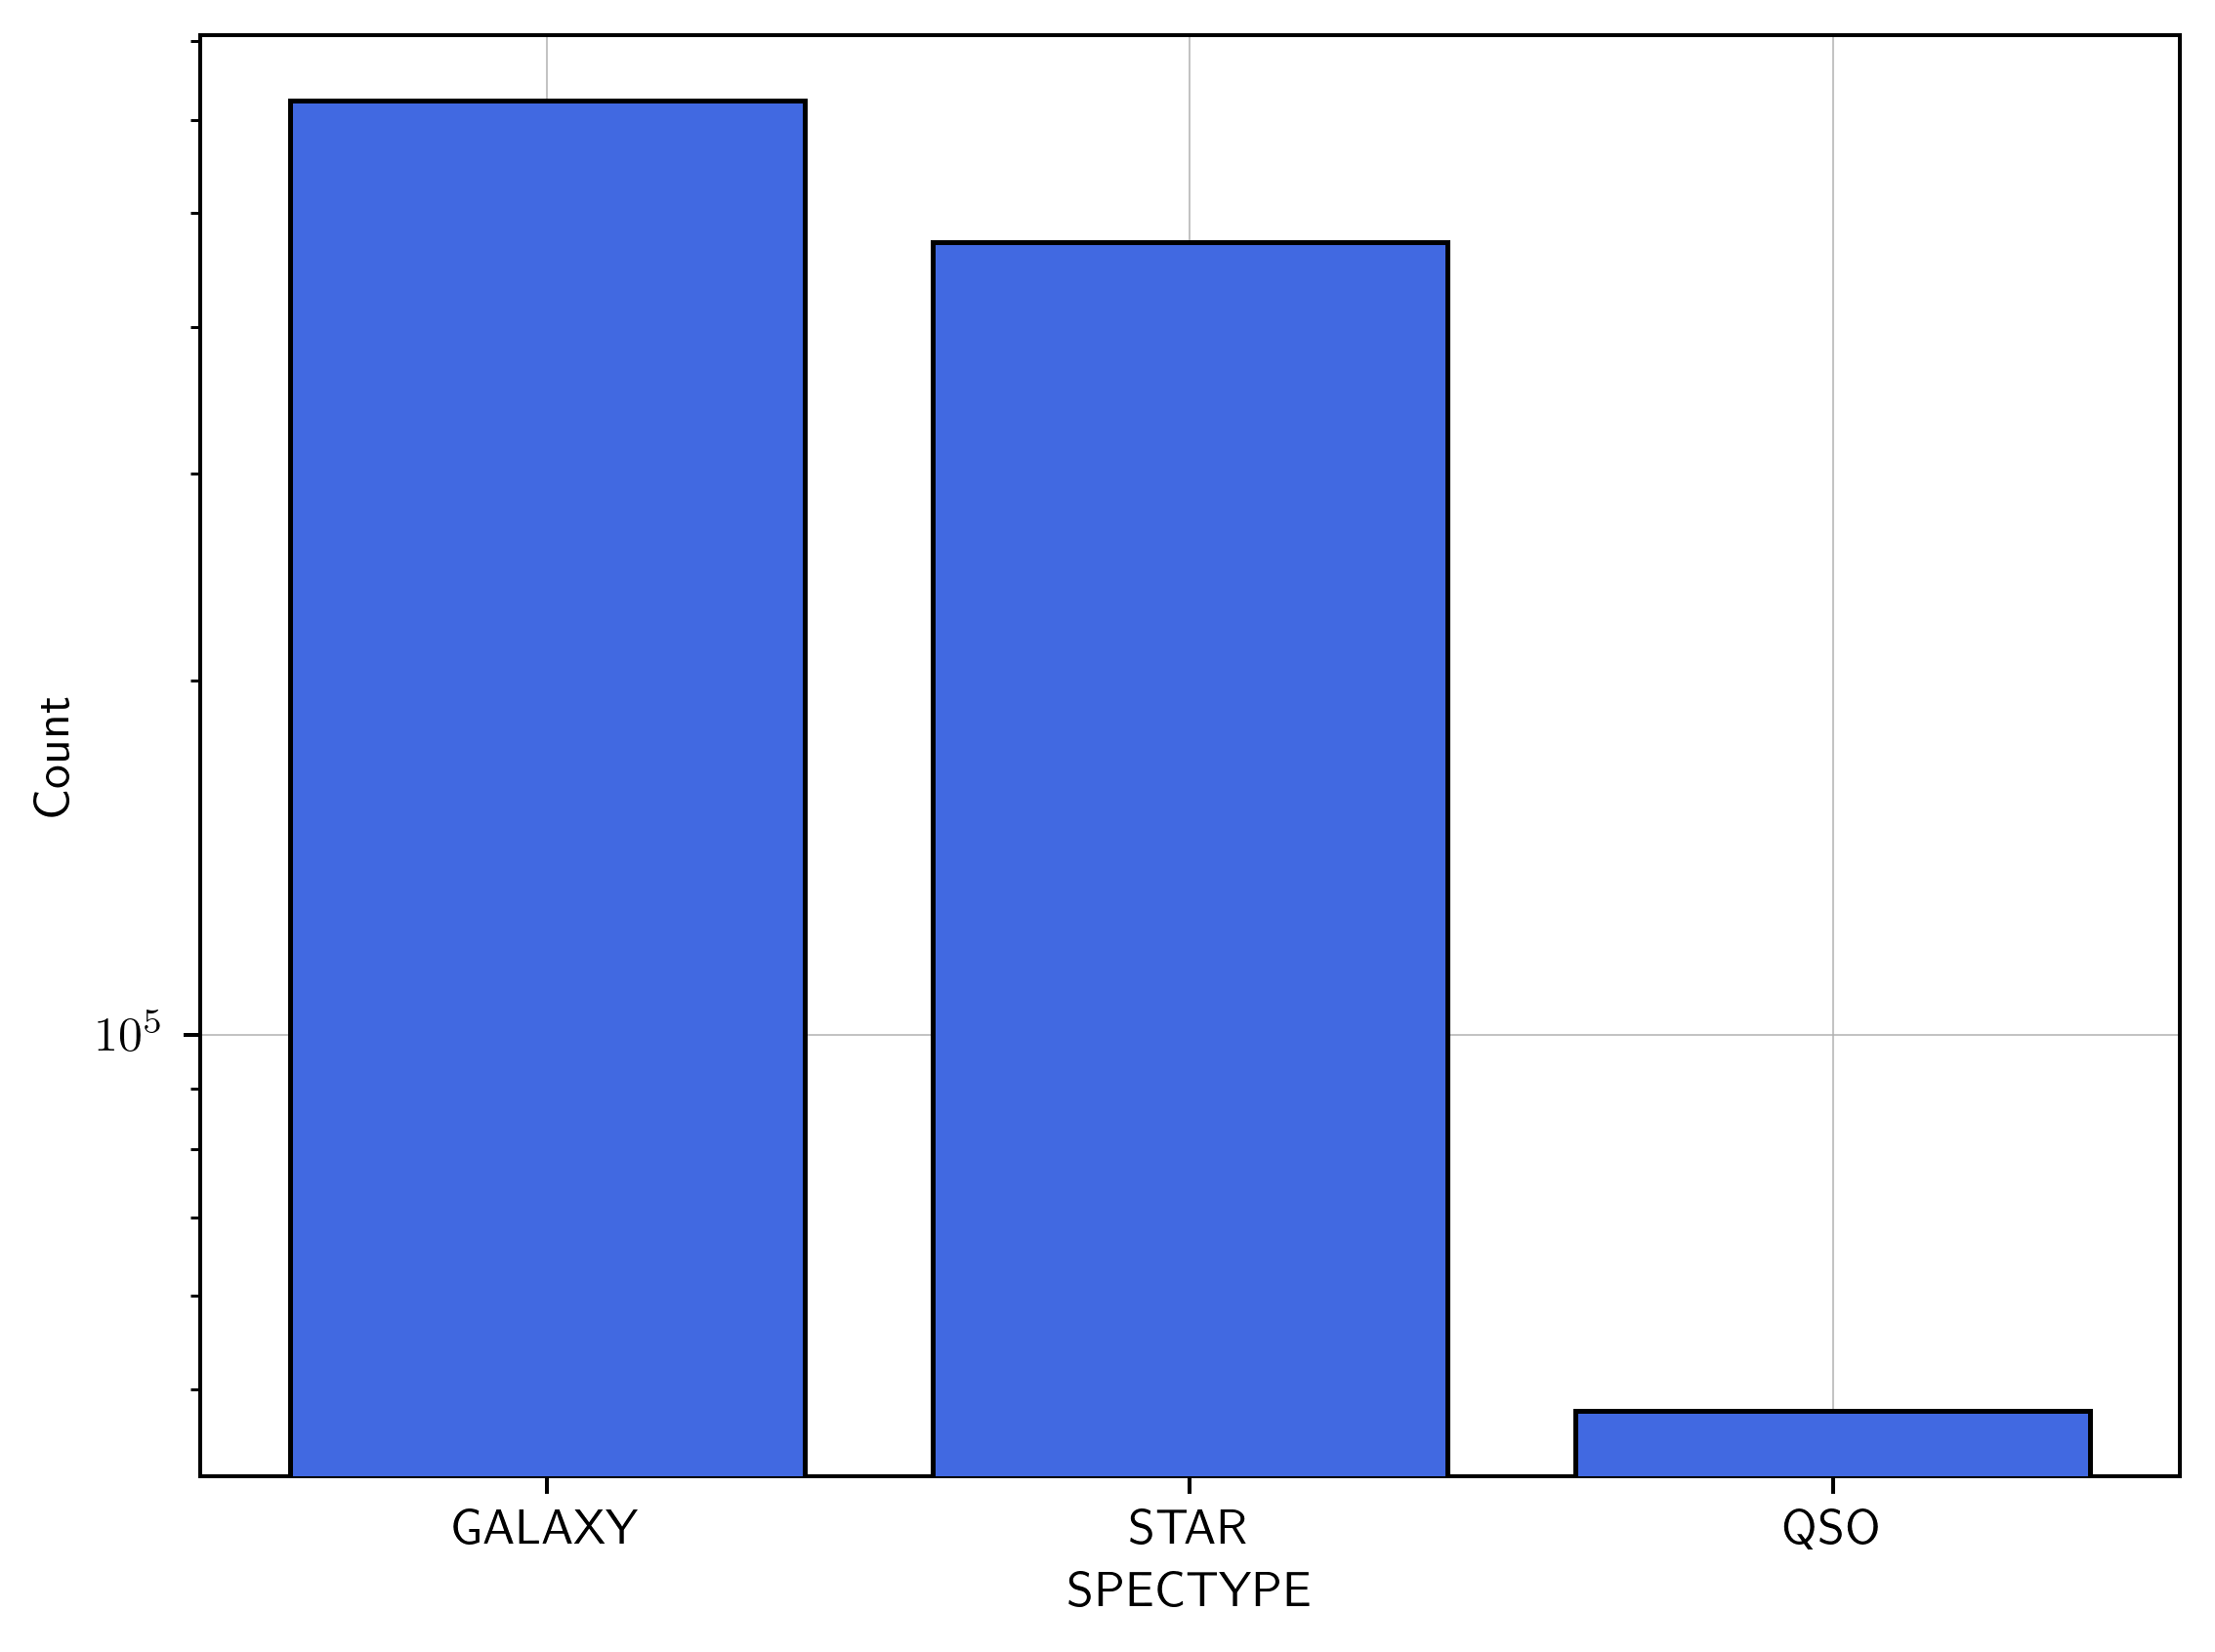

In [ ]:
conteos = dfs['SPECTYPE'].value_counts()


plt.figure()
plt.grid(linewidth=0.3, zorder=-1)
plt.bar(conteos.index.astype(str), conteos.values, color='royalblue', edgecolor='black', zorder=10)

plt.xlabel('SPECTYPE')
plt.yscale('log')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import h5py

archivo = h5py.File('/pscratch/sd/v/vtorresg/umap_analysis/data/processed/20231013-4666-3.h5', 'r')
print(list(archivo.keys()))

['metadata', 'spectra']


In [ ]:
folder = Path('/pscratch/sd/v/vtorresg/umap_analysis/data/processed/')
conteo_total = Counter()

In [ ]:
for i, archivo_h5 in enumerate(folder.glob('*.h5')):
    if i%1000==0:
        print(i)
    try:
        with h5py.File(archivo_h5, 'r') as f:
            types = f['metadata']['types'][:]
            types = [x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in types]
            conteo_total.update(types)
    except Exception as e:
        print(f'Error con {archivo_h5}: {e}')

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000


In [ ]:
for tipo, n in conteo_total.items():
    print(f'{tipo}: {n}')

STAR: 13877554
GALAXY: 39734157
QSO: 4679623


In [41]:
4679623+39734157+13877554

58291334

In [ ]:
ls = []

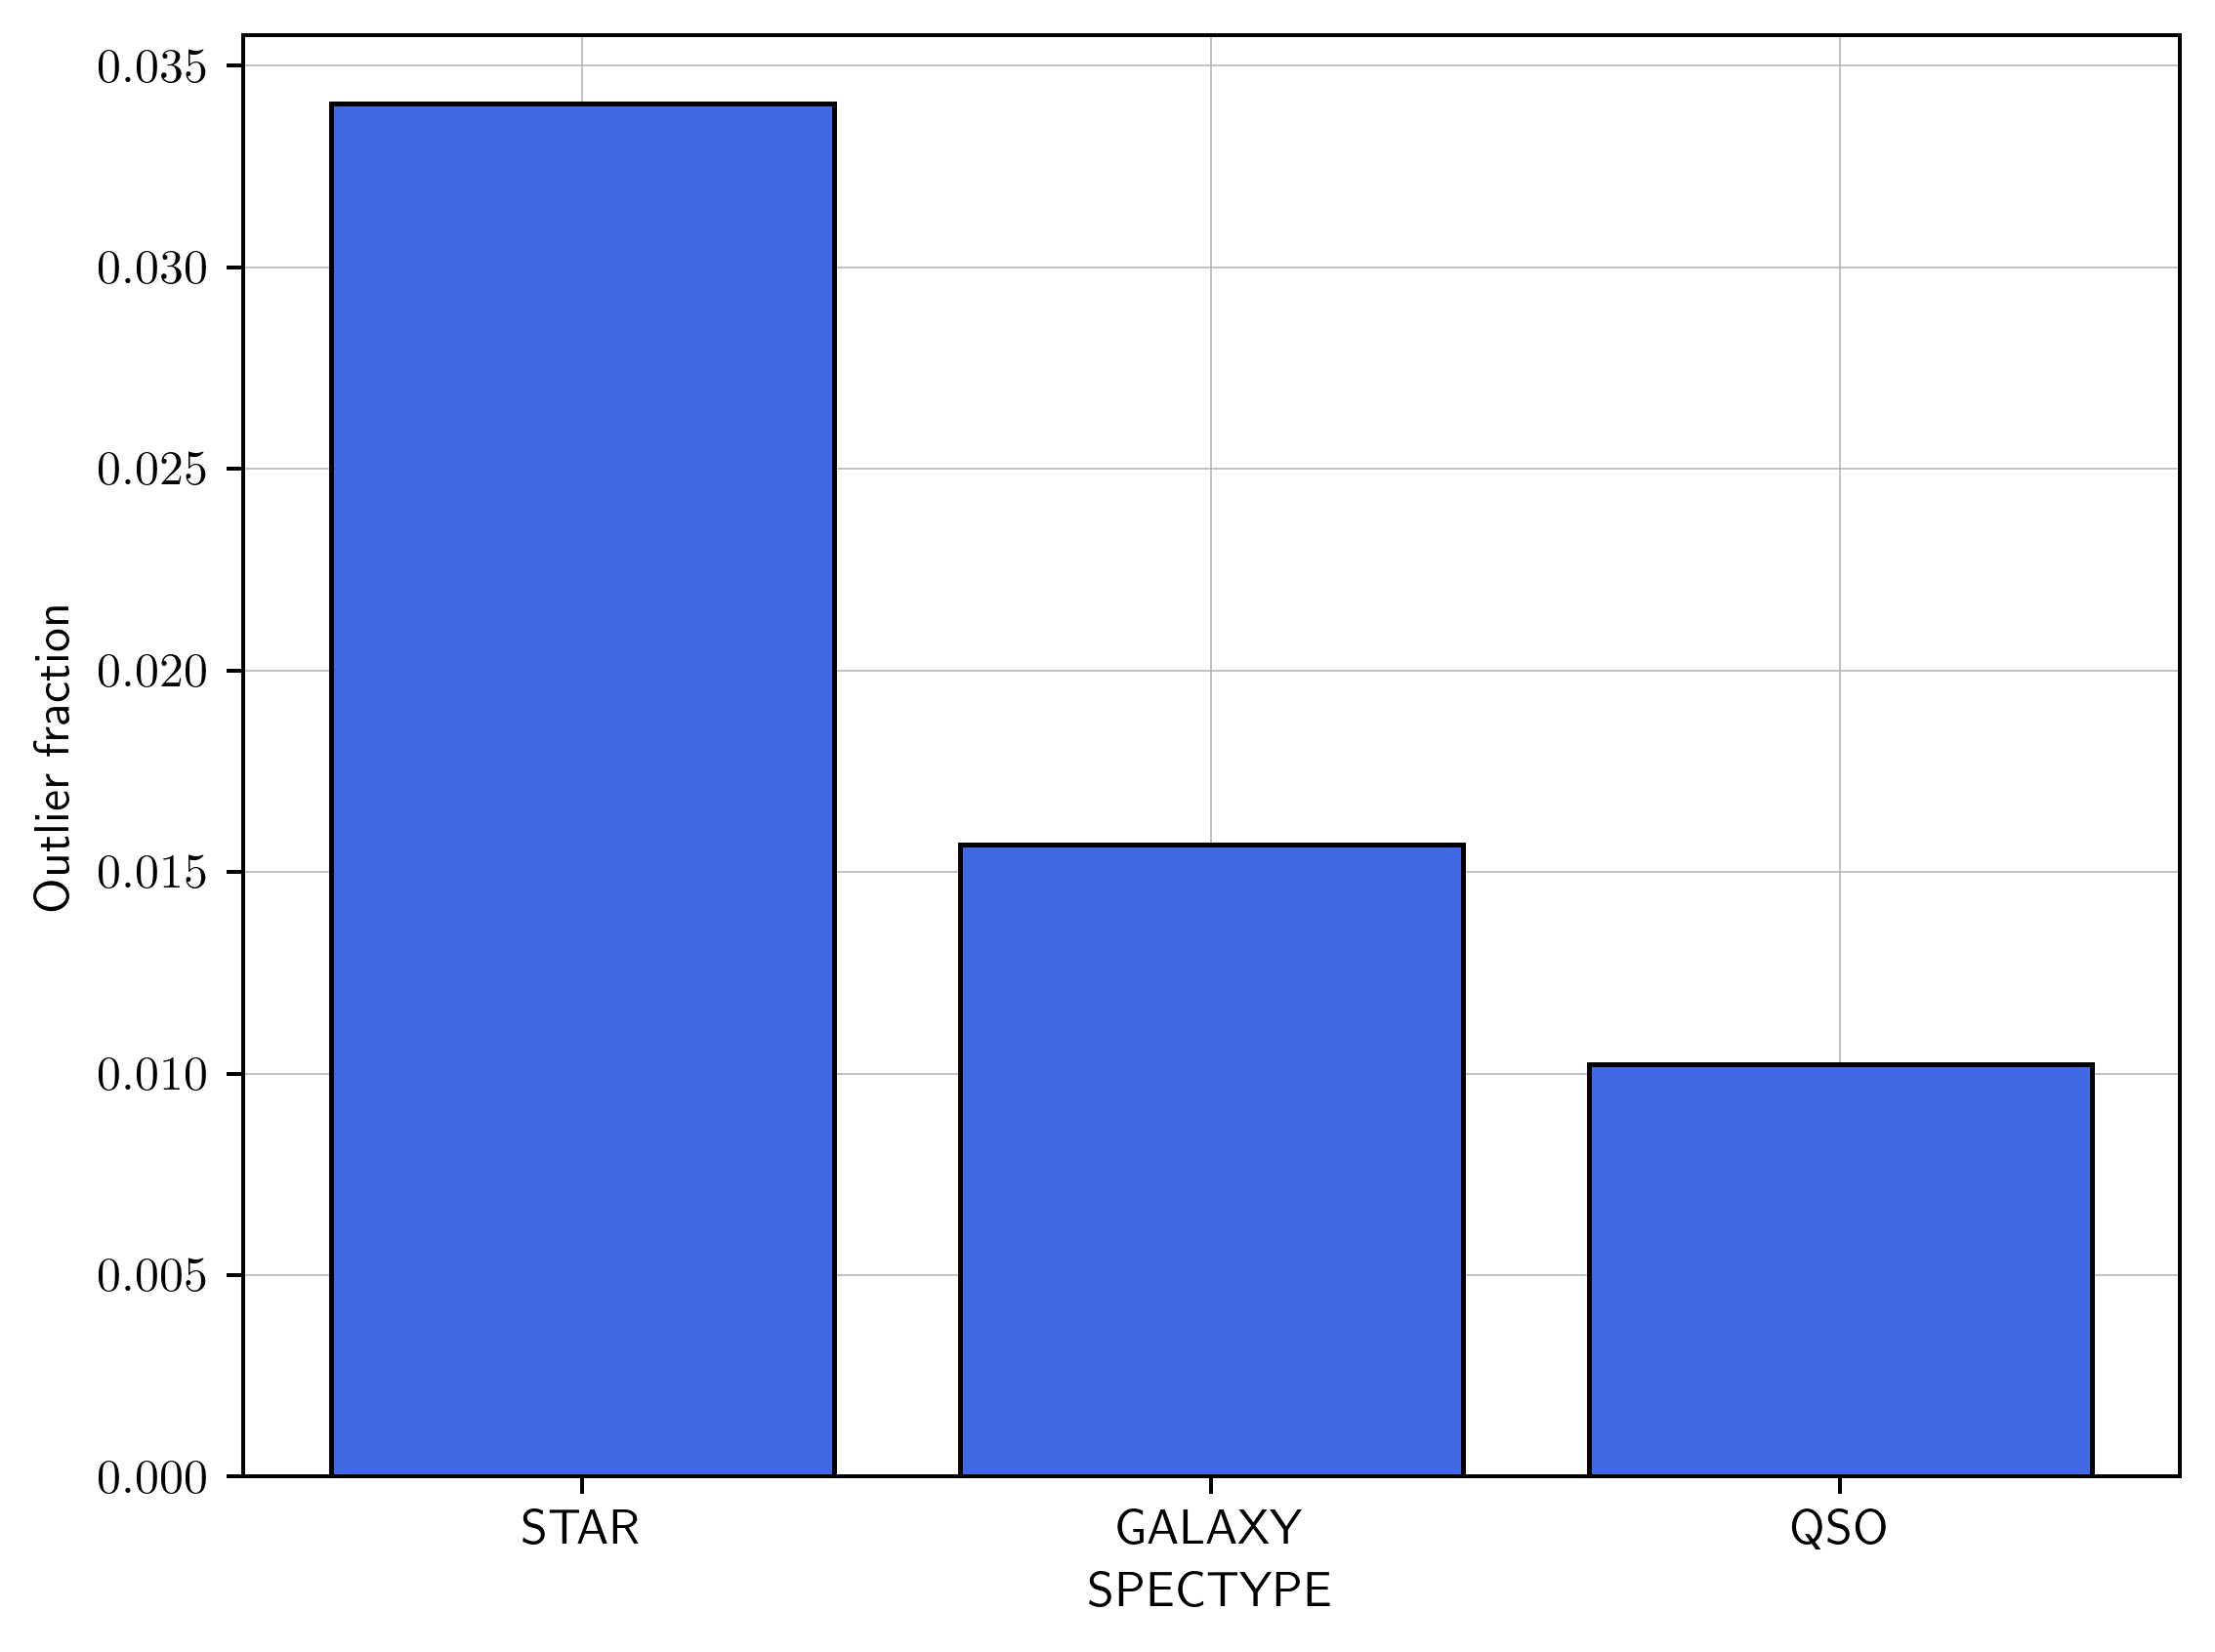

In [ ]:
conteos = dfs['SPECTYPE'].value_counts()

totales = pd.Series({
    'STAR': 13877554,
    'GALAXY': 39734157,
    'QSO': 4679623
})

conteos, totales = conteos.align(totales, join='right', fill_value=0)

frac = (conteos / totales)*1#00

plt.figure()
plt.grid(linewidth=0.3, zorder=-1)
plt.bar(frac.index.astype(str), frac.values, color='royalblue', edgecolor='black', zorder=10)

plt.xlabel('SPECTYPE')
plt.ylabel('Outlier fraction')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('out_fraction_spec.png', dpi=360)
plt.show()

In [ ]:
folder = Path('/pscratch/sd/v/vtorresg/umap_analysis/data/processed/')
conteo_por_tile = defaultdict(Counter)

In [ ]:
for i, archivo_h5 in enumerate(folder.glob('*.h5')):
    if i % 1000 == 0:
        print(i)

    try:
        partes = archivo_h5.stem.split('-')
        if len(partes) != 3:
            continue

        night, tile, rosette = partes
        tile = int(tile)

        with h5py.File(archivo_h5, 'r') as f:
            types = f['metadata']['types'][:]
            types = [
                x.decode('utf-8') if isinstance(x, bytes) else str(x)
                for x in types
            ]

        conteo_por_tile[tile].update(types)

    except Exception as e:
        print(f'Error con {archivo_h5}: {e}')

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000


In [ ]:
df_out = dfs.copy()
df_out['TILE'] = df_out['TILE'].astype(int)
df_out['SPECTYPE'] = df_out['SPECTYPE'].astype(str)

df_out_tile = (
    df_out.groupby(['TILE', 'SPECTYPE'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['STAR', 'GALAXY', 'QSO']:
    if col not in df_out_tile.columns:
        df_out_tile[col] = 0

df_out_tile = df_out_tile[['TILE', 'STAR', 'GALAXY', 'QSO']]
df_out_tile = df_out_tile.rename(columns={
    'STAR': 'STAR_out',
    'GALAXY': 'GALAXY_out',
    'QSO': 'QSO_out'
})

print('Outliers por tile:')
print(df_out_tile.head())


rows = []
for tile, counter in conteo_por_tile.items():
    row = {'TILE': tile}
    row.update(counter)
    rows.append(row)

df_tot_tile = pd.DataFrame(rows).fillna(0)

for col in ['STAR', 'GALAXY', 'QSO']:
    if col not in df_tot_tile.columns:
        df_tot_tile[col] = 0

df_tot_tile = df_tot_tile[['TILE', 'STAR', 'GALAXY', 'QSO']]
df_tot_tile = df_tot_tile.rename(columns={
    'STAR': 'STAR_tot',
    'GALAXY': 'GALAXY_tot',
    'QSO': 'QSO_tot'
})

print('Totales por tile:')
print(df_tot_tile.head())


df_tile = df_tot_tile.merge(df_out_tile, on='TILE', how='left').fillna(0)

for t in ['STAR', 'GALAXY', 'QSO']:
    df_tile[f'{t}_out'] = df_tile[f'{t}_out'].astype(int)
    df_tile[f'{t}_tot'] = df_tile[f'{t}_tot'].astype(int)

    df_tile[f'f_{t}'] = np.where(
        df_tile[f'{t}_tot'] > 0,
        df_tile[f'{t}_out'] / df_tile[f'{t}_tot'],
        np.nan
    )

print(df_tile[['TILE', 'STAR_tot', 'STAR_out', 'f_STAR']].head())


min_n = 20

for t in ['STAR', 'GALAXY', 'QSO']:
    df_tile.loc[df_tile[f'{t}_tot'] < min_n, f'f_{t}'] = np.nan


types = ['STAR', 'GALAXY', 'QSO']
medians = []
err_low = []
err_high = []

for t in types:
    vals = df_tile[f'f_{t}'].dropna()

    q16 = vals.quantile(0.16)
    q50 = vals.quantile(0.50)
    q84 = vals.quantile(0.84)

    medians.append(q50)
    err_low.append(q50 - q16)
    err_high.append(q84 - q50)

    print(
        t,
        f'Ntiles={len(vals)}',
        f'median={q50:.4f}',
        f'q16={q16:.4f}',
        f'q84={q84:.4f}'
    )

yerr = np.array([err_low, err_high])

Outliers por tile:
SPECTYPE  TILE  STAR_out  GALAXY_out  QSO_out
0            1         0          13        7
1            2         1          15        7
2            3         0          18        1
3            4         0          14        4
4            5         0          35        2
Totales por tile:
    TILE  STAR_tot  GALAXY_tot  QSO_tot
0  41771      5012          44      4.0
1  25860      1244        3714     63.0
2  22882      1368        4315     82.0
3   8404       437        4562   1270.0
4  27153      3621        1785     37.0
    TILE  STAR_tot  STAR_out    f_STAR
0  41771      5012       259  0.051676
1  25860      1244        19  0.015273
2  22882      1368        11  0.008041
3   8404       437         1  0.002288
4  27153      3621        37  0.010218
STAR Ntiles=14199 median=0.0088 q16=0.0000 q84=0.0277
GALAXY Ntiles=14191 median=0.0104 q16=0.0037 q84=0.0322
QSO Ntiles=13643 median=0.0086 q16=0.0015 q84=0.0612


STAR Ntiles=14199 median=0.0088 q16=0.0000 q84=0.0277
GALAXY Ntiles=14191 median=0.0104 q16=0.0037 q84=0.0322
QSO Ntiles=13643 median=0.0086 q16=0.0015 q84=0.0612


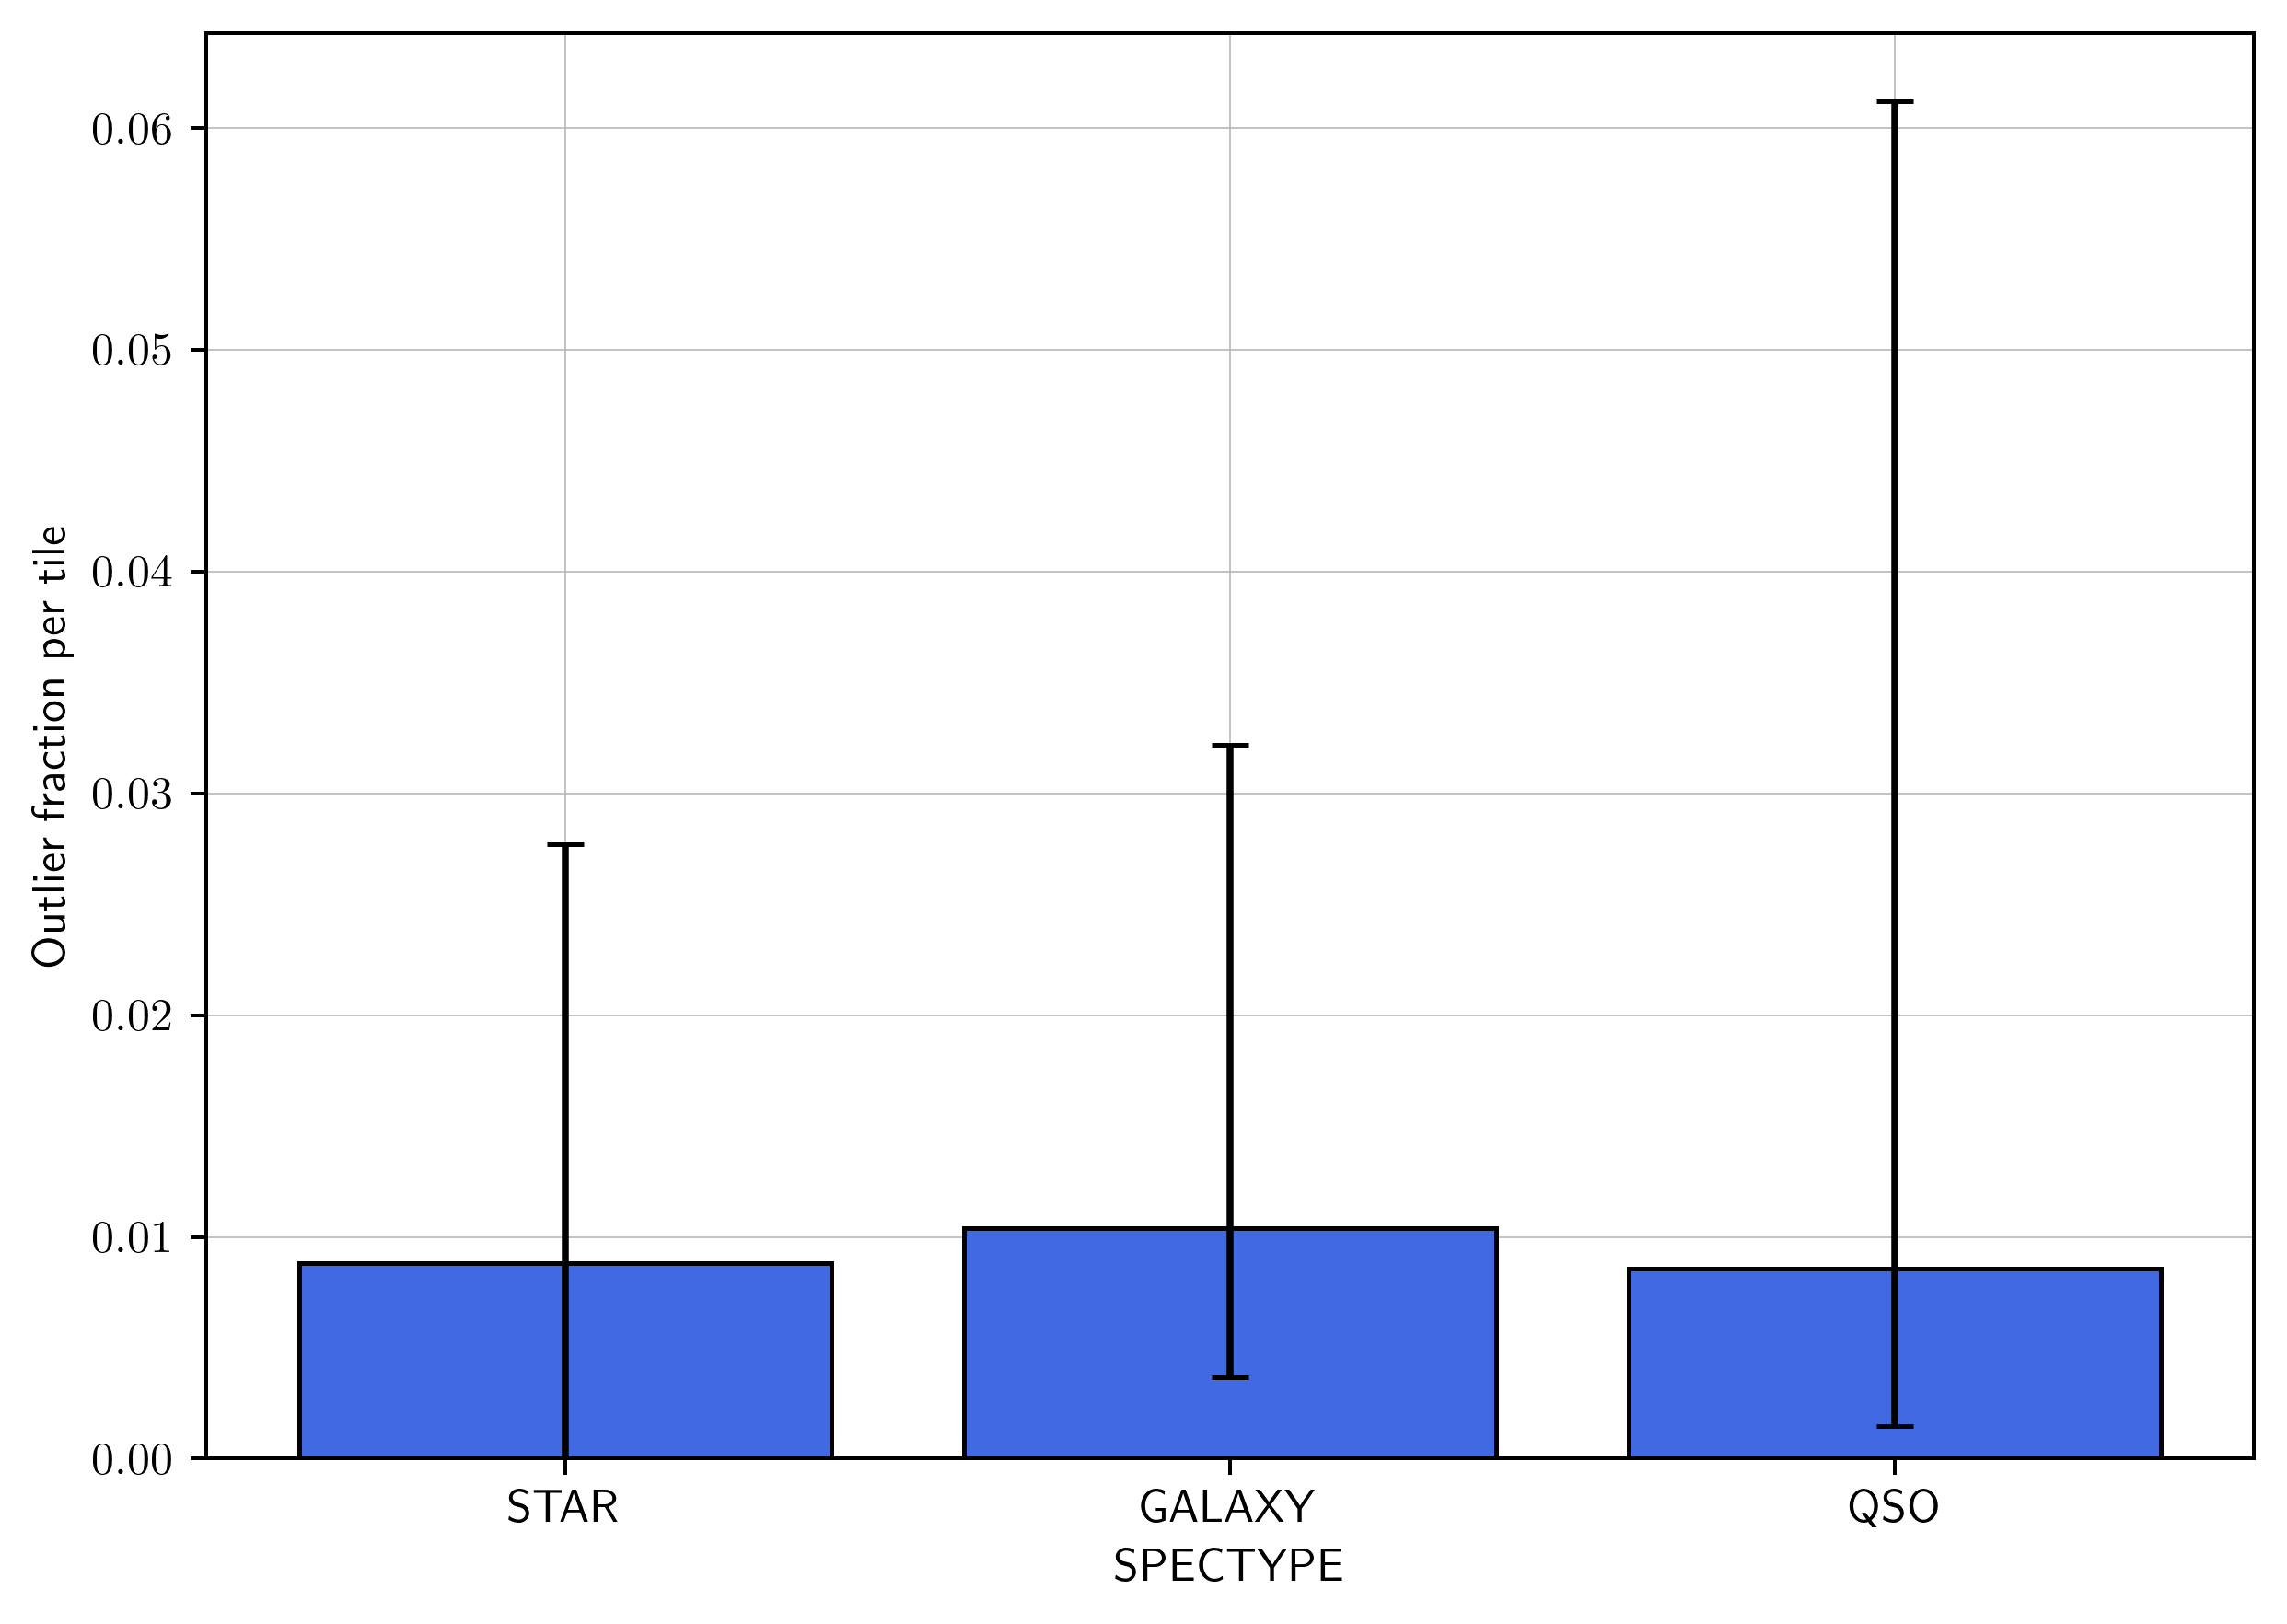

In [ ]:
min_n = 20

for t in ['STAR', 'GALAXY', 'QSO']:
    df_tile.loc[df_tile[f'{t}_tot'] < min_n, f'f_{t}'] = np.nan

types = ['STAR', 'GALAXY', 'QSO']
medians = []
err_low = []
err_high = []

for t in types:
    vals = df_tile[f'f_{t}'].dropna()

    q16 = vals.quantile(0.16)
    q50 = vals.quantile(0.50)
    q84 = vals.quantile(0.84)

    medians.append(q50)
    err_low.append(q50 - q16)
    err_high.append(q84 - q50)

    print(
        t,
        f'Ntiles={len(vals)}',
        f'median={q50:.4f}',
        f'q16={q16:.4f}',
        f'q84={q84:.4f}'
    )

yerr = np.array([err_low, err_high])


plt.figure(figsize=(7, 5))
plt.grid(linewidth=0.3, zorder=-1)

plt.bar(types, medians, color='royalblue', edgecolor='black', zorder=10)
plt.errorbar(types, medians, yerr=yerr, fmt='none', ecolor='black', capsize=4, zorder=20)

plt.xlabel('SPECTYPE')
plt.ylabel('Outlier fraction per tile')
plt.tight_layout()
plt.savefig('out_spec_tile.png', dpi=360)
plt.show()

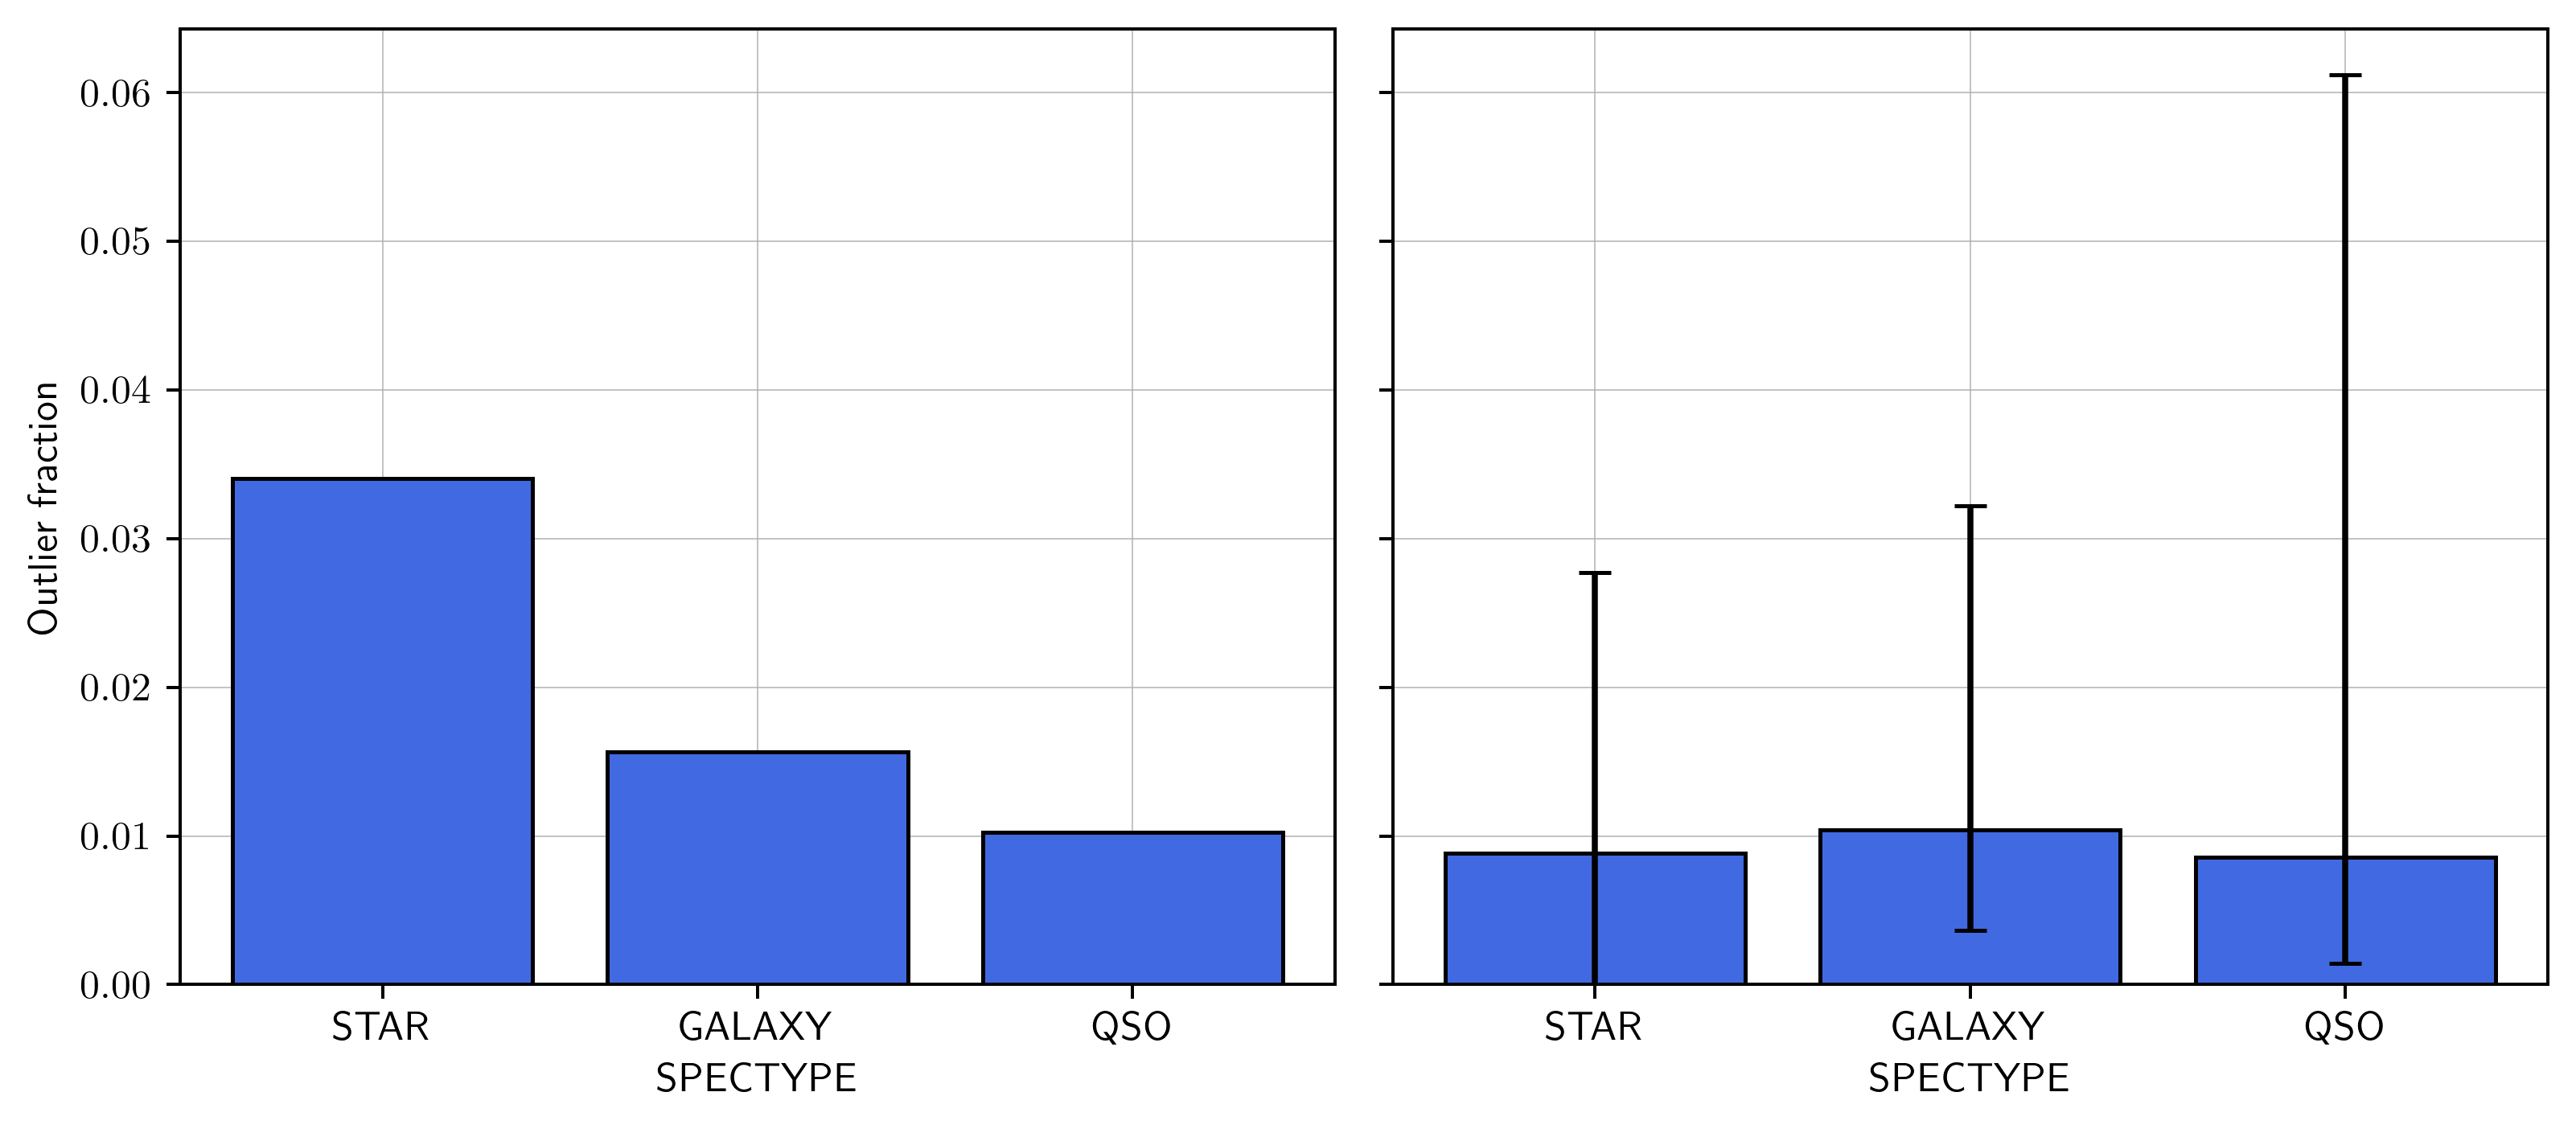

In [ ]:
conteos = dfs['SPECTYPE'].value_counts()

totales = pd.Series({
    'STAR': 13877554,
    'GALAXY': 39734157,
    'QSO': 4679623
})

conteos, totales = conteos.align(totales, join='right', fill_value=0)
frac = conteos / totales

types = ['STAR', 'GALAXY', 'QSO']
medians = []
err_low = []
err_high = []

for t in types:
    vals = df_tile[f'f_{t}'].dropna()
    q16 = vals.quantile(0.16)
    q50 = vals.quantile(0.50)
    q84 = vals.quantile(0.84)

    medians.append(q50)
    err_low.append(q50 - q16)
    err_high.append(q84 - q50)

yerr = np.array([err_low, err_high])

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

axes[0].grid(linewidth=0.3, zorder=-1)
axes[0].bar(frac.index.astype(str), frac.values,
            color='royalblue', edgecolor='black', zorder=10)
axes[0].set_xlabel('SPECTYPE')
axes[0].set_ylabel('Outlier fraction')
# axes[0].set_title('(a) Global')

axes[1].grid(linewidth=0.3, zorder=-1)
axes[1].bar(types, medians,
            color='royalblue', edgecolor='black', zorder=10)
axes[1].errorbar(types, medians, yerr=yerr,
                 fmt='none', ecolor='black', capsize=4, zorder=20)
axes[1].set_xlabel('SPECTYPE')
# axes[1].set_title('(b) Per tile')

plt.tight_layout()
plt.savefig('out_fraction_spec_combined.png', dpi=360)
plt.show()

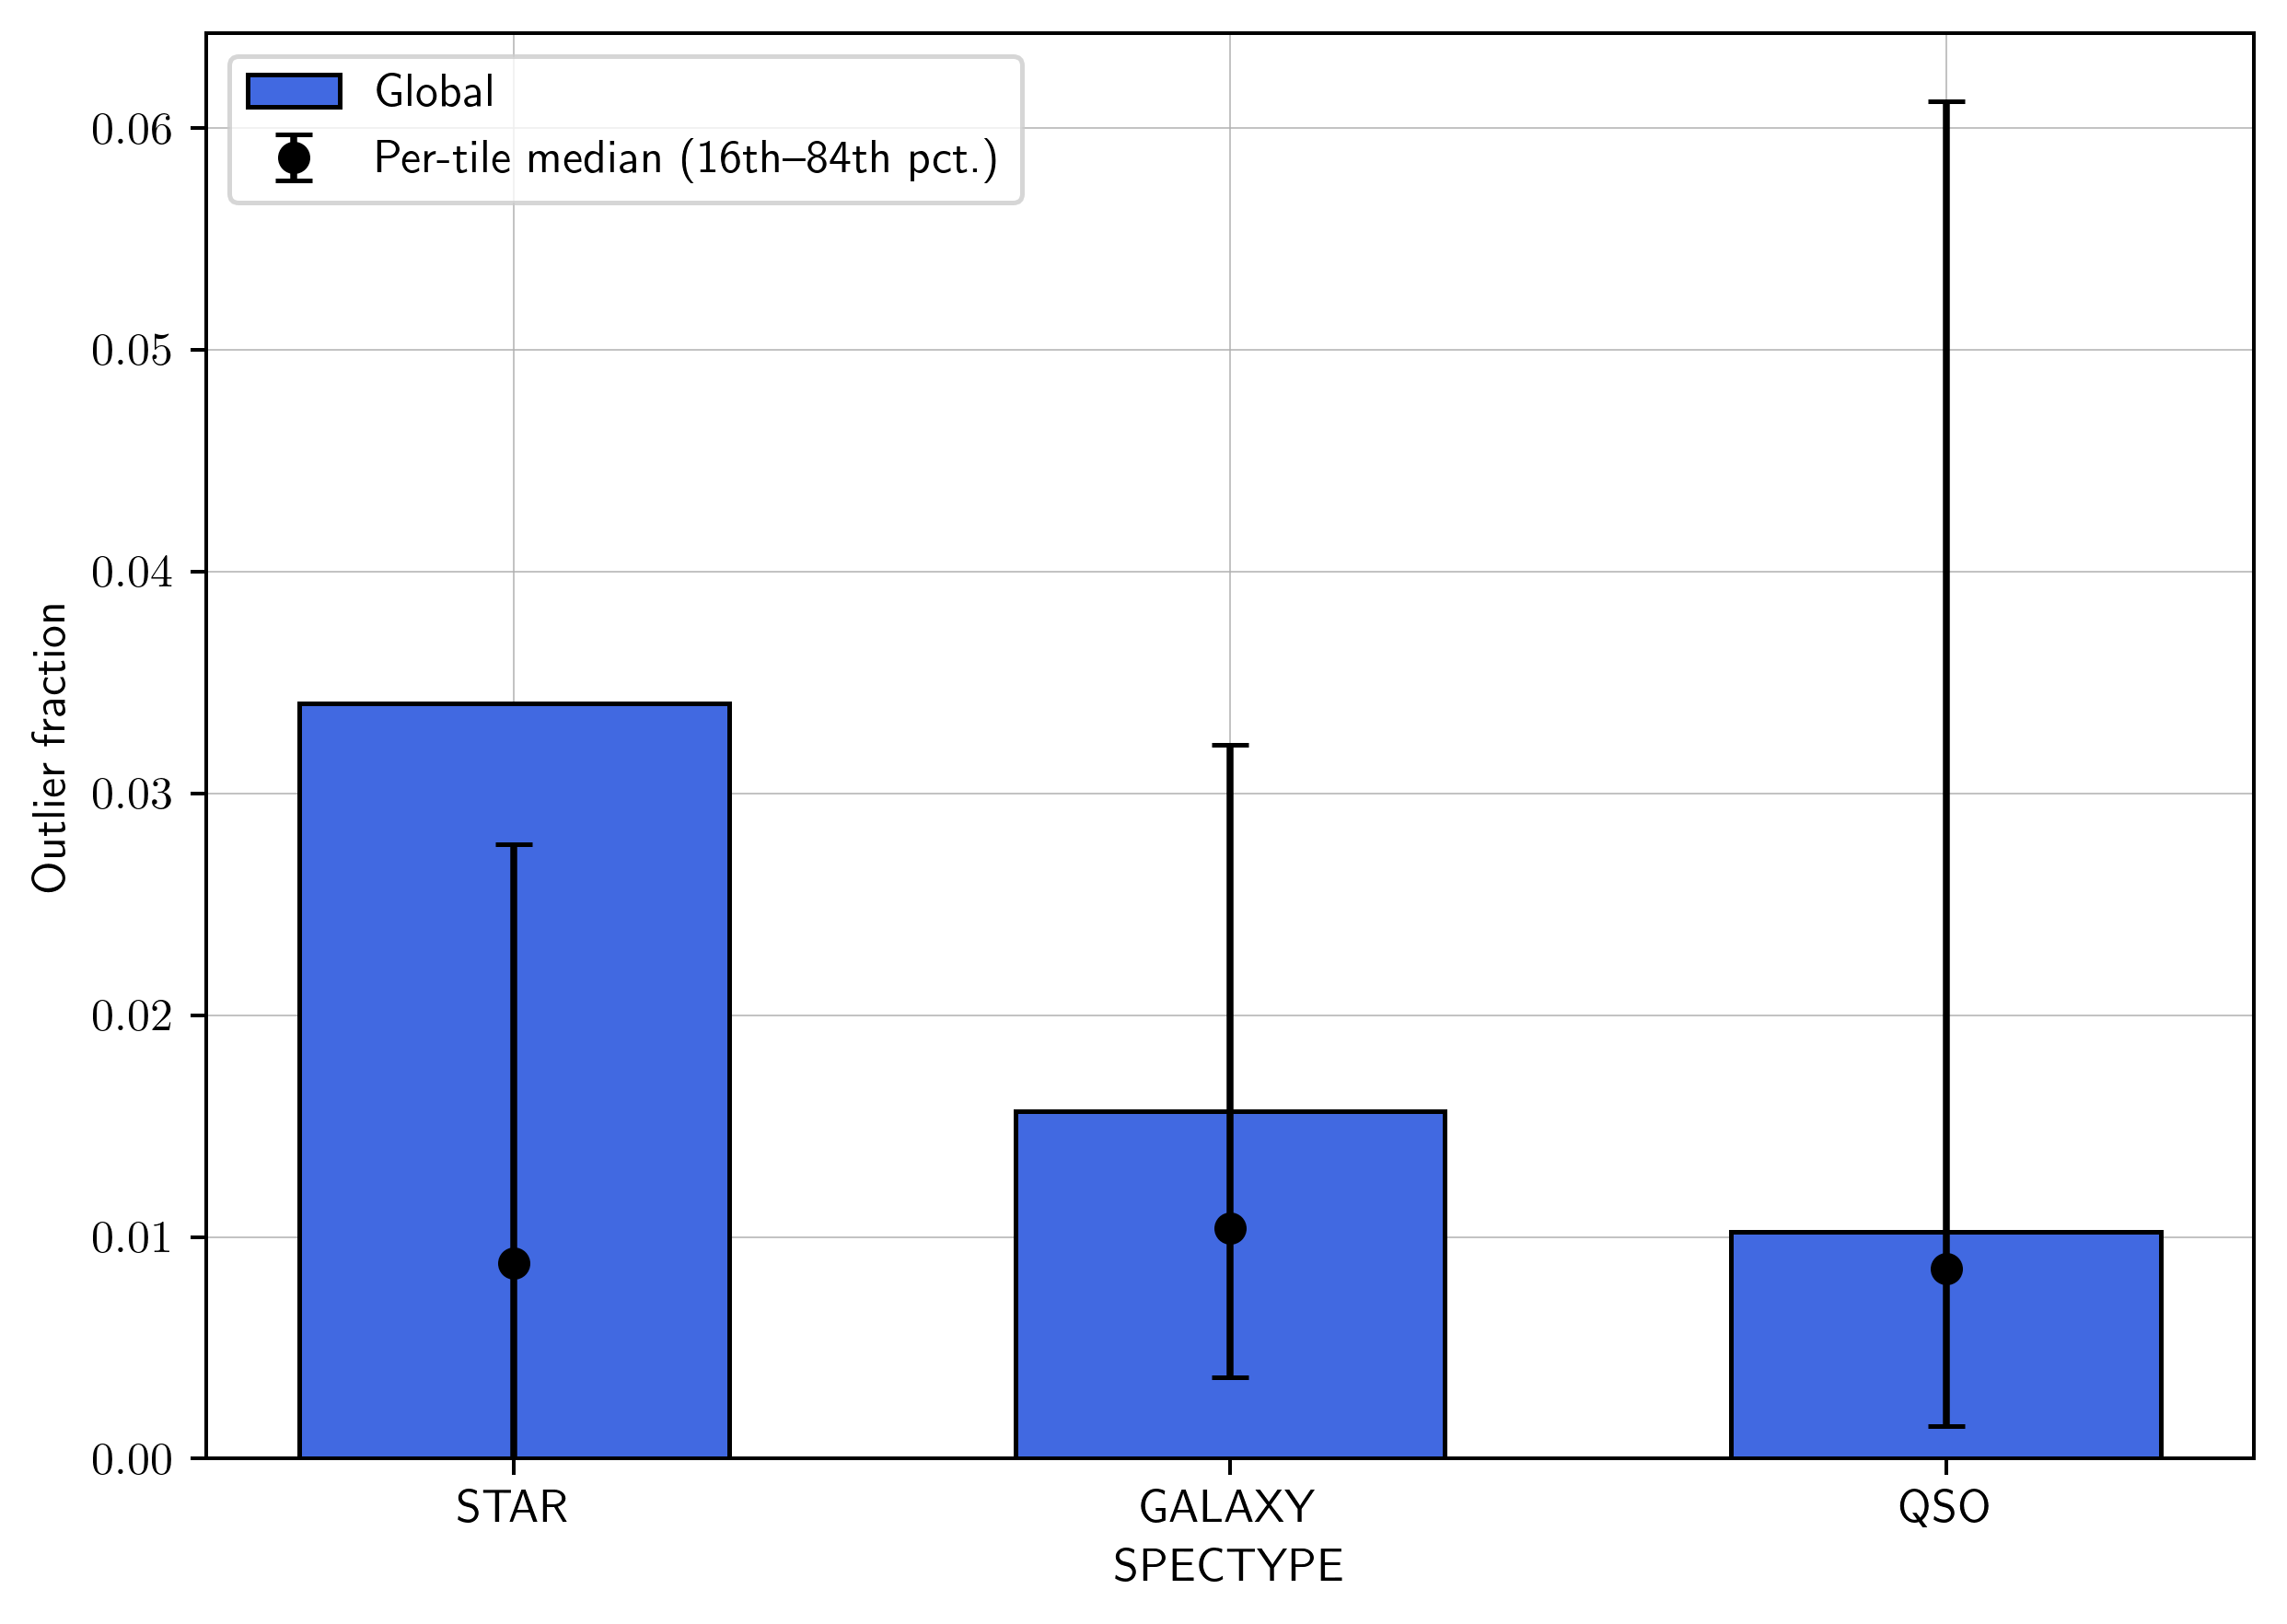

In [ ]:
conteos = dfs['SPECTYPE'].value_counts()

totales = pd.Series({
    'STAR': 13877554,
    'GALAXY': 39734157,
    'QSO': 4679623
})

conteos, totales = conteos.align(totales, join='right', fill_value=0)
frac_global = conteos / totales

types = ['STAR', 'GALAXY', 'QSO']
global_vals = np.array([frac_global.get(t, np.nan) for t in types])

medians = []
err_low = []
err_high = []

for t in types:
    vals = df_tile[f'f_{t}'].dropna()

    q16 = vals.quantile(0.16)
    q50 = vals.quantile(0.50)
    q84 = vals.quantile(0.84)

    medians.append(q50)
    err_low.append(q50 - q16)
    err_high.append(q84 - q50)

medians = np.array(medians)
yerr = np.array([err_low, err_high])

x = np.arange(len(types))

plt.figure(figsize=(7,5))
plt.grid(linewidth=0.3, zorder=-1)

plt.bar(
    x, global_vals,
    width=0.6,
    color='royalblue',
    edgecolor='black',
    zorder=10,
    label='Global'
)

plt.errorbar(
    x, medians, yerr=yerr,
    fmt='o',
    color='black',
    capsize=4,
    zorder=20,
    label='Per-tile median (16th--84th pct.)'
)

plt.xticks(x, types)
plt.xlabel('SPECTYPE')
plt.ylabel('Outlier fraction')
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('out_fraction_spec_onepanel.png', dpi=360)
plt.show()

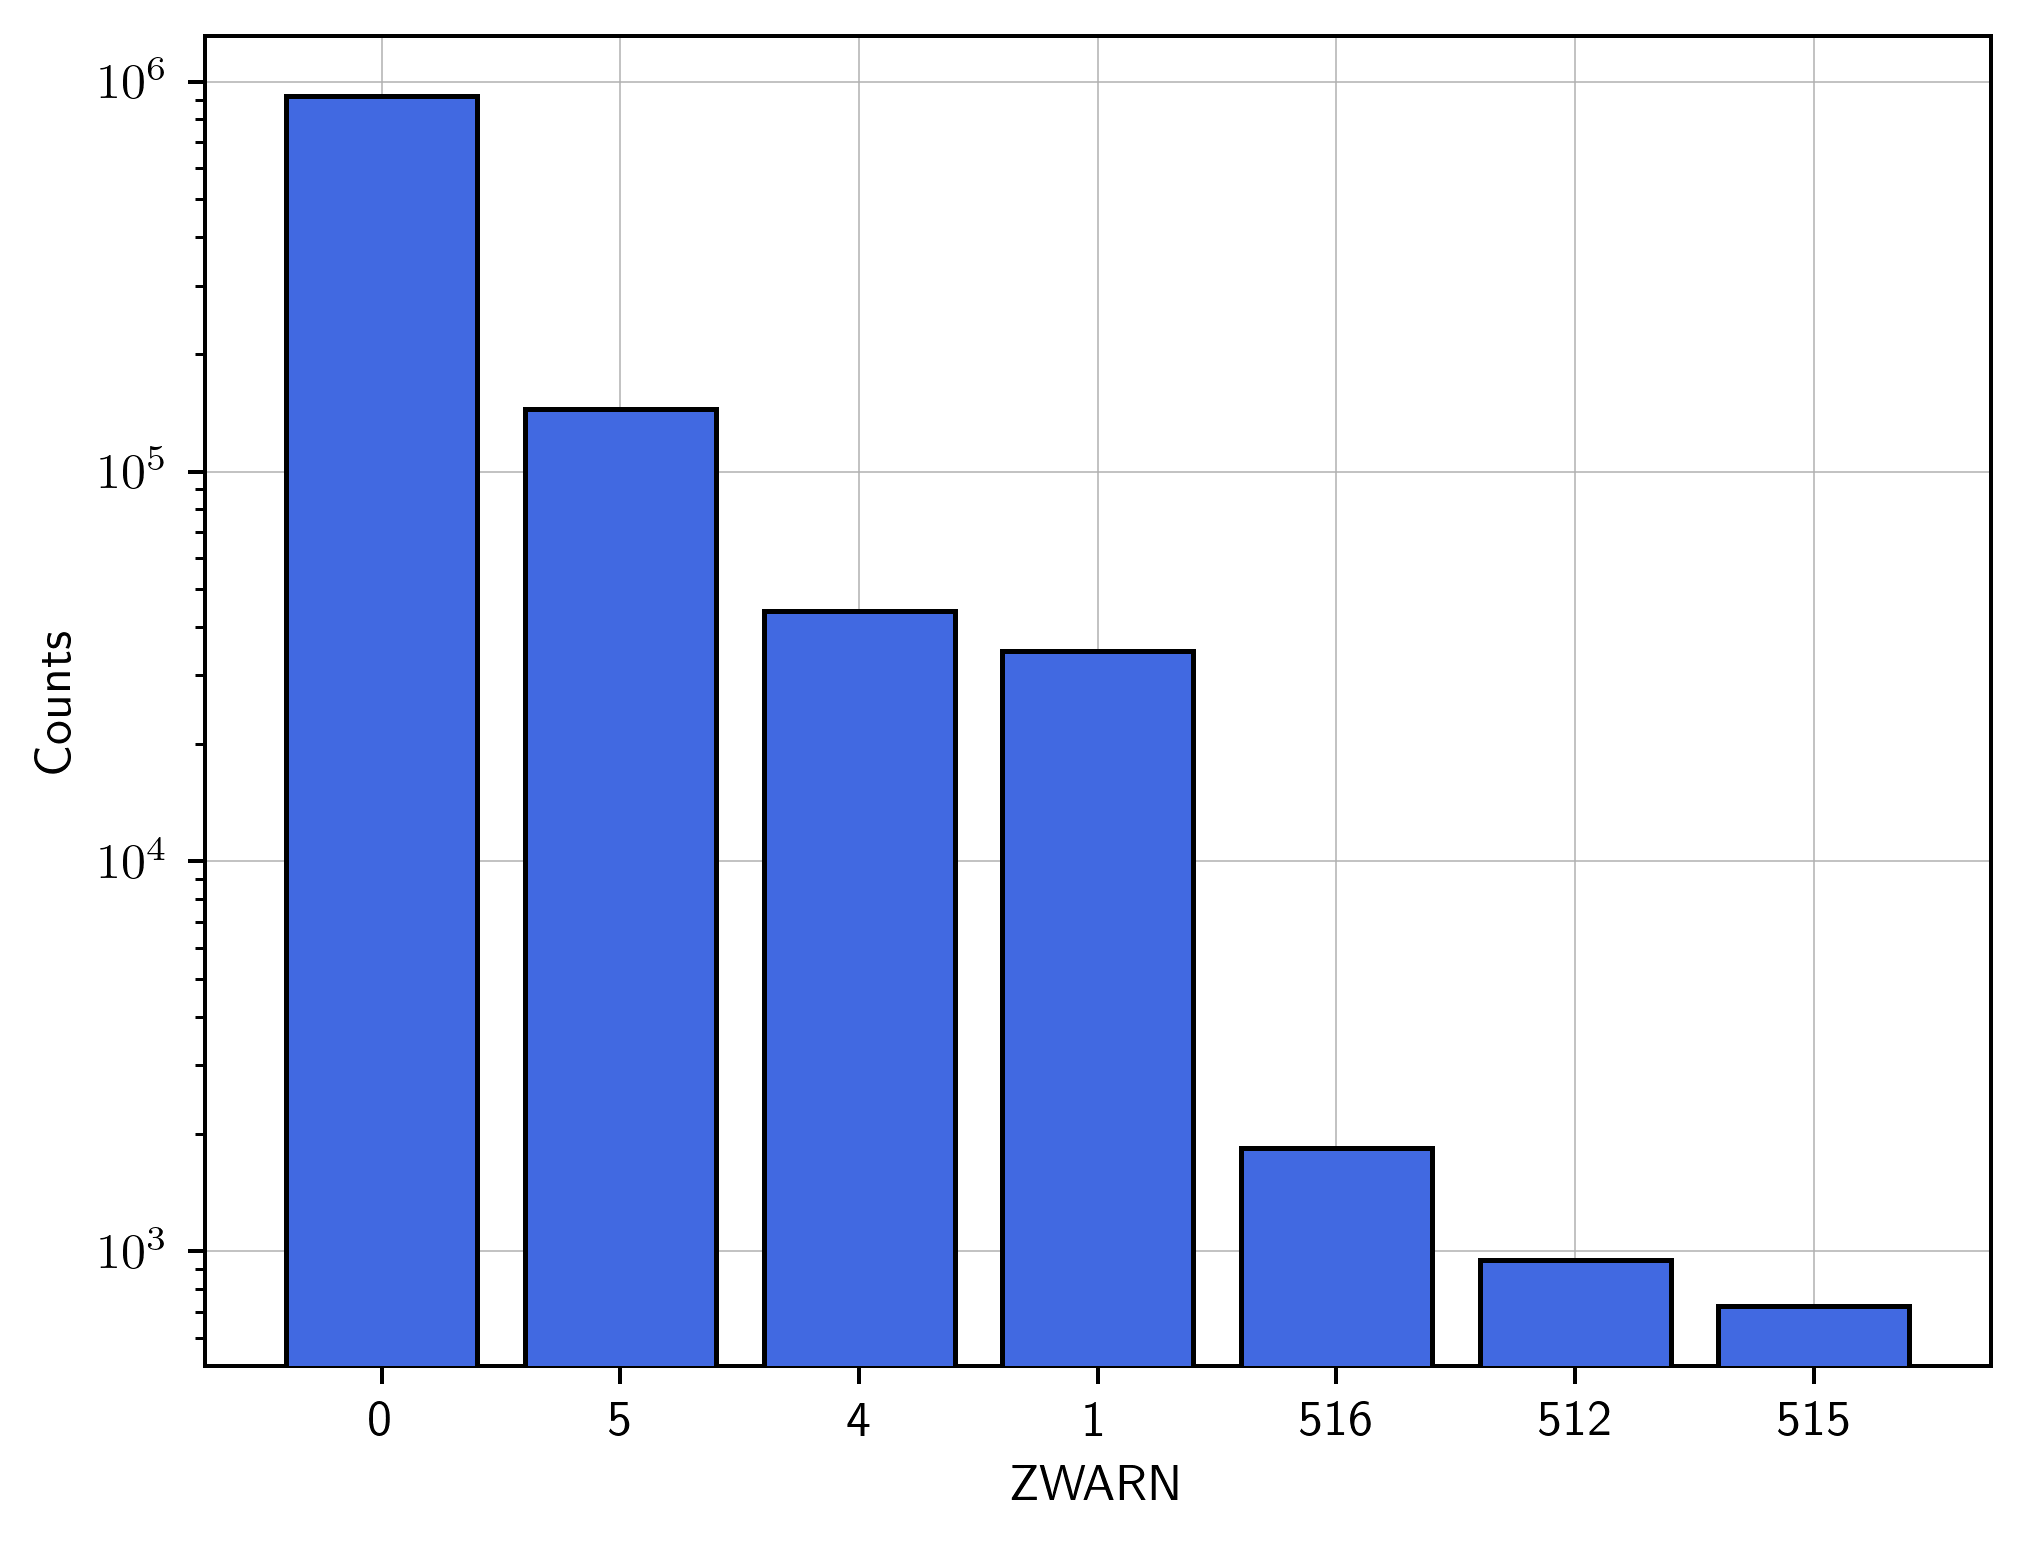

In [ ]:
counts = dfs['ZWARN'].value_counts().sort_values(ascending=False)

top_counts = counts.head(10)

plt.figure()
plt.grid(linewidth=0.3, zorder=-1)
plt.bar(top_counts.index.astype(str), top_counts.values, color='royalblue', edgecolor='black', zorder=10)

plt.xlabel('ZWARN')
plt.ylabel('Counts')
plt.yscale('log')
# plt.savefig('zwarn.png', dpi=360)
plt.show()

In [353]:
np.unique(dfs[dfs['SUBTYPES']=='[]']['TILE'])

array([80615])

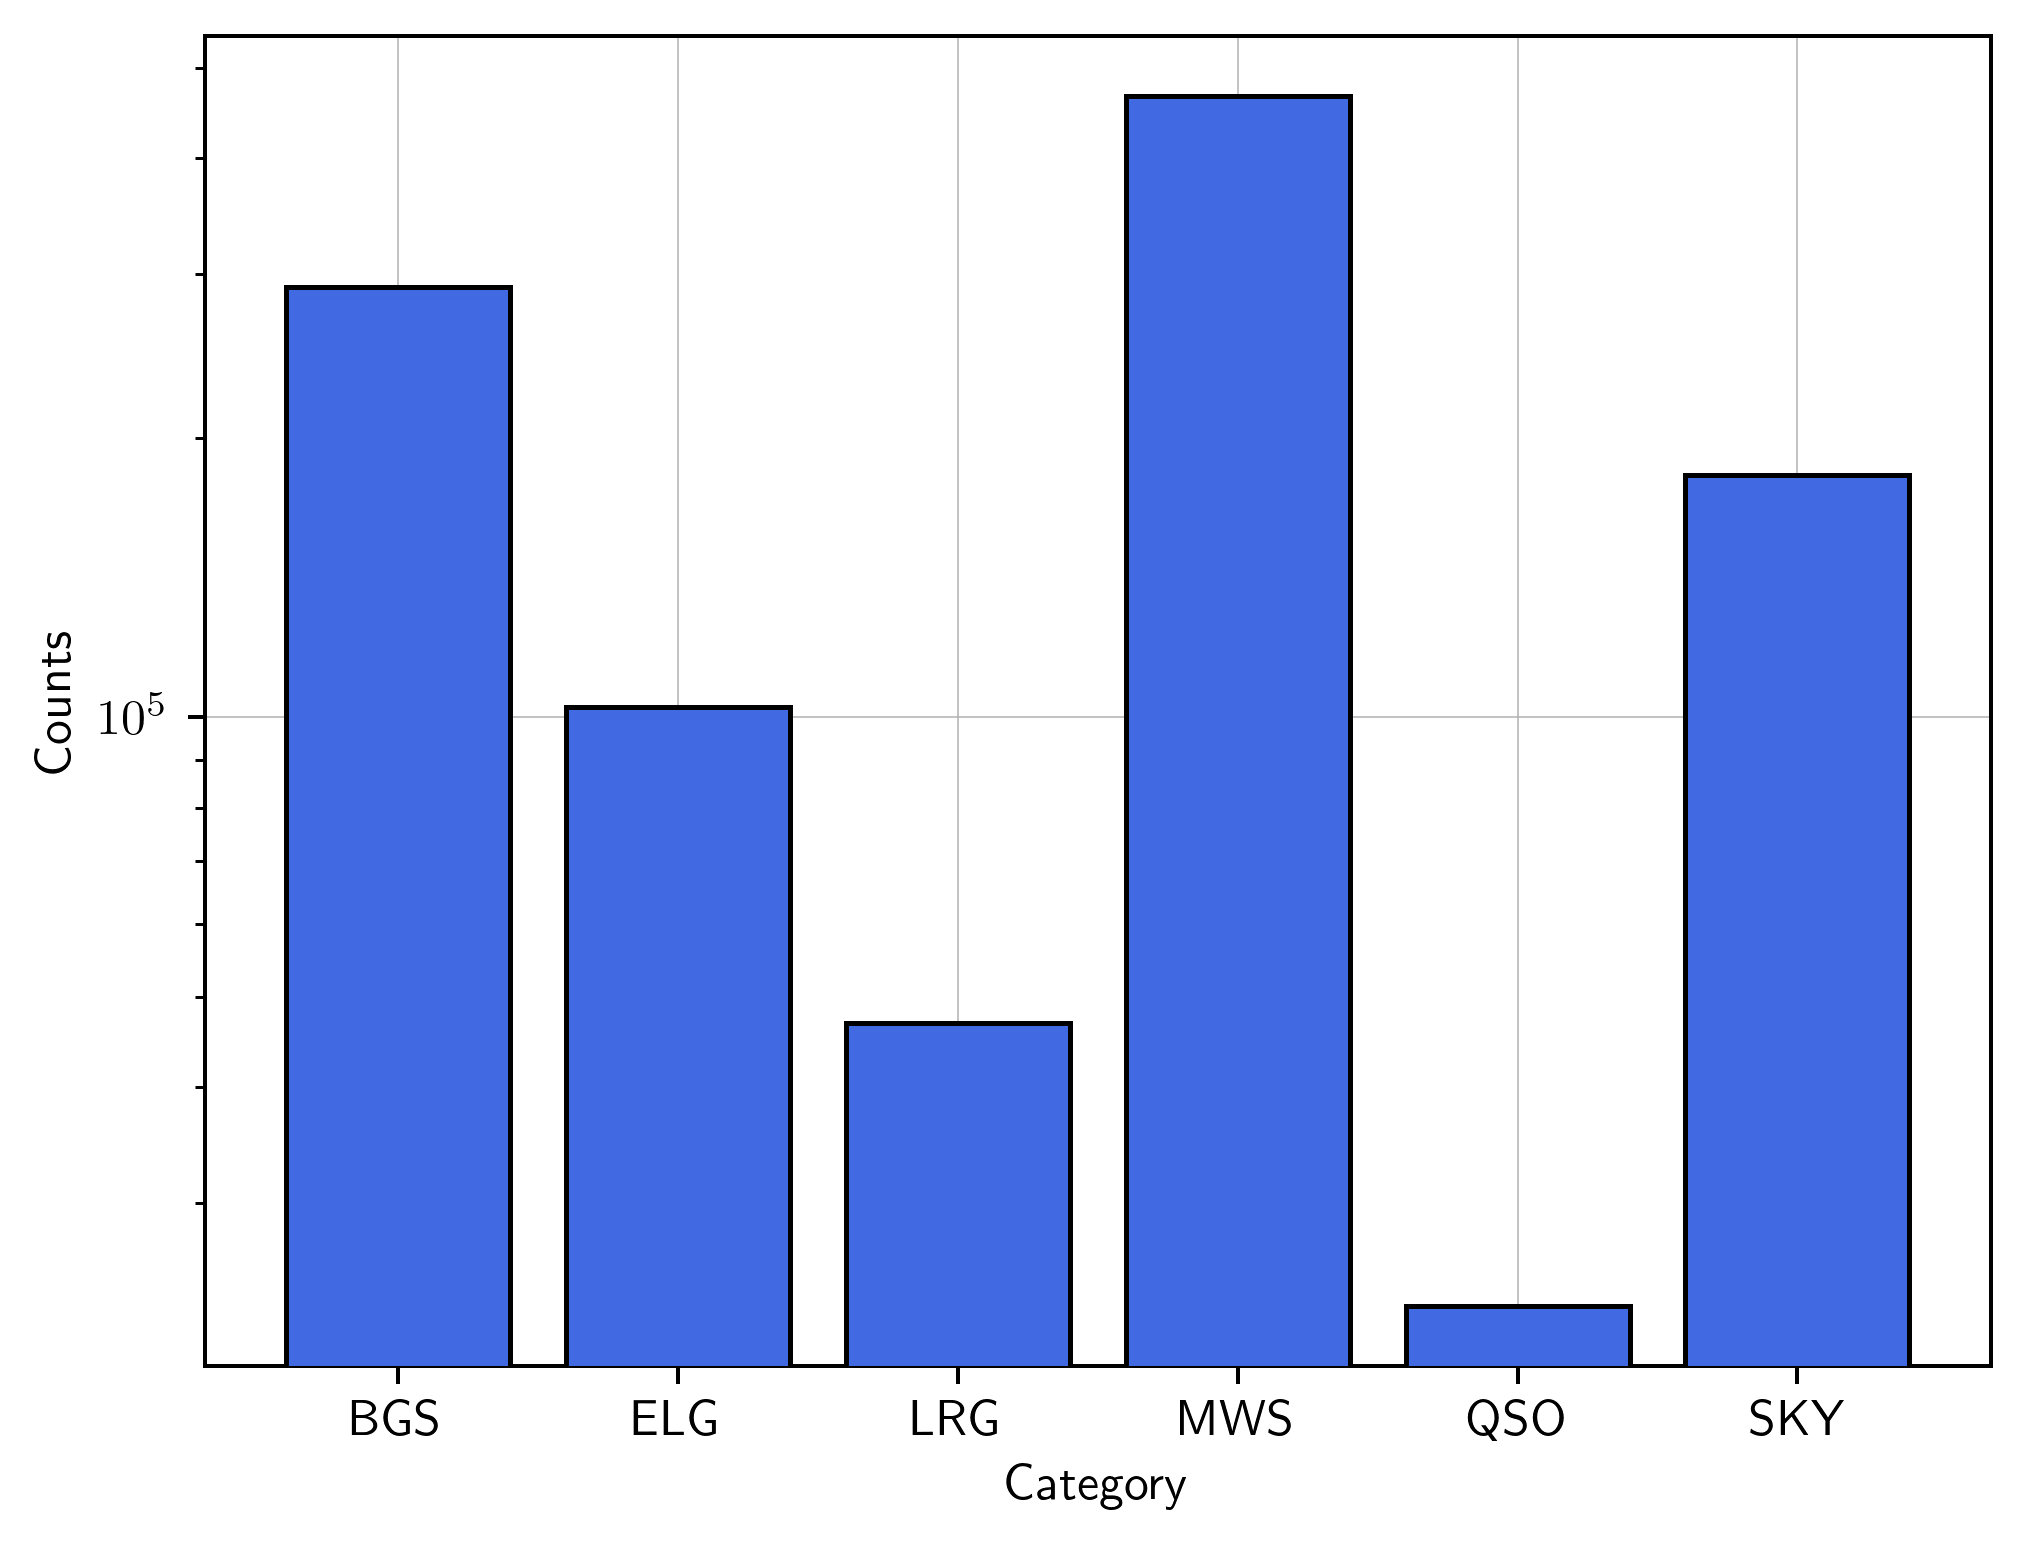

In [ ]:
counts = dfs['CATEGORY'].value_counts().sort_index()

plt.figure()
plt.grid(linewidth=0.3, zorder=-1)

plt.bar(counts.index, counts.values, color='royalblue', edgecolor='black', zorder=10)

plt.xlabel('Category')
plt.ylabel('Counts')
# plt.title('Outlier counts', fontsize=14)
plt.yscale('log')
# plt.savefig('cat.png', dpi=360)
plt.show()

In [356]:
import pandas as pd
from redrock.zwarning import ZWarningMask as ZW

In [357]:
ZW_BITS = {name: getattr(ZW, name) for name in dir(ZW) if name.isupper()}

In [ ]:
def decode_zwarn(v):
    if v == 0:
        return ['NONE']
    out = []
    for name, bit in ZW_BITS.items():
        if v & bit:
            out.append(name)
    return out

In [ ]:
dfs['ZWARN_FLAGS'] = dfs['ZWARN'].apply(decode_zwarn)
dfs.head()

,TARGETID,TILE,NIGHT,SPECTYPE,SUBTYPES,CATEGORY,ZWARN,R,ZWARN_FLAGS
0,39627697512518406,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,4,3,[SMALL_DELTA_CHI2]
1,39627703543927450,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,0,4,[NONE]
2,39627709575332142,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,0,4,[NONE]
3,39627709600501233,3157,20220408,GALAXY,"['MAIN:LRG', 'MAIN:LRG_SOUTH']",LRG,0,6,[NONE]
4,39627709600500439,3157,20220408,GALAXY,"['MAIN:ELG', 'MAIN:ELG_LOP', 'MAIN:ELG_SOUTH',...",ELG,0,6,[NONE]


In [ ]:
df_flags = dfs.explode('ZWARN_FLAGS', ignore_index=True)
# df_flags = df_flags[df_flags['ZWARN_FLAGS'] != 'NONE']

In [ ]:
counts = df_flags['ZWARN_FLAGS'].value_counts().sort_values(ascending=False)
counts

ZWARN_FLAGS
NONE                916911
SMALL_DELTA_CHI2    189957
SKY                 179734
NODATA                3514
LITTLE_COVERAGE        724
Name: count, dtype: int64

In [362]:
pretty = {'NONE': 'None',
          'SMALL_DELTA_CHI2': r'Small $\Delta \chi^2$',
          'SKY': 'Sky',
          'NODATA': 'No data',
          'LITTLE_COVERAGE': 'Little coverage'}

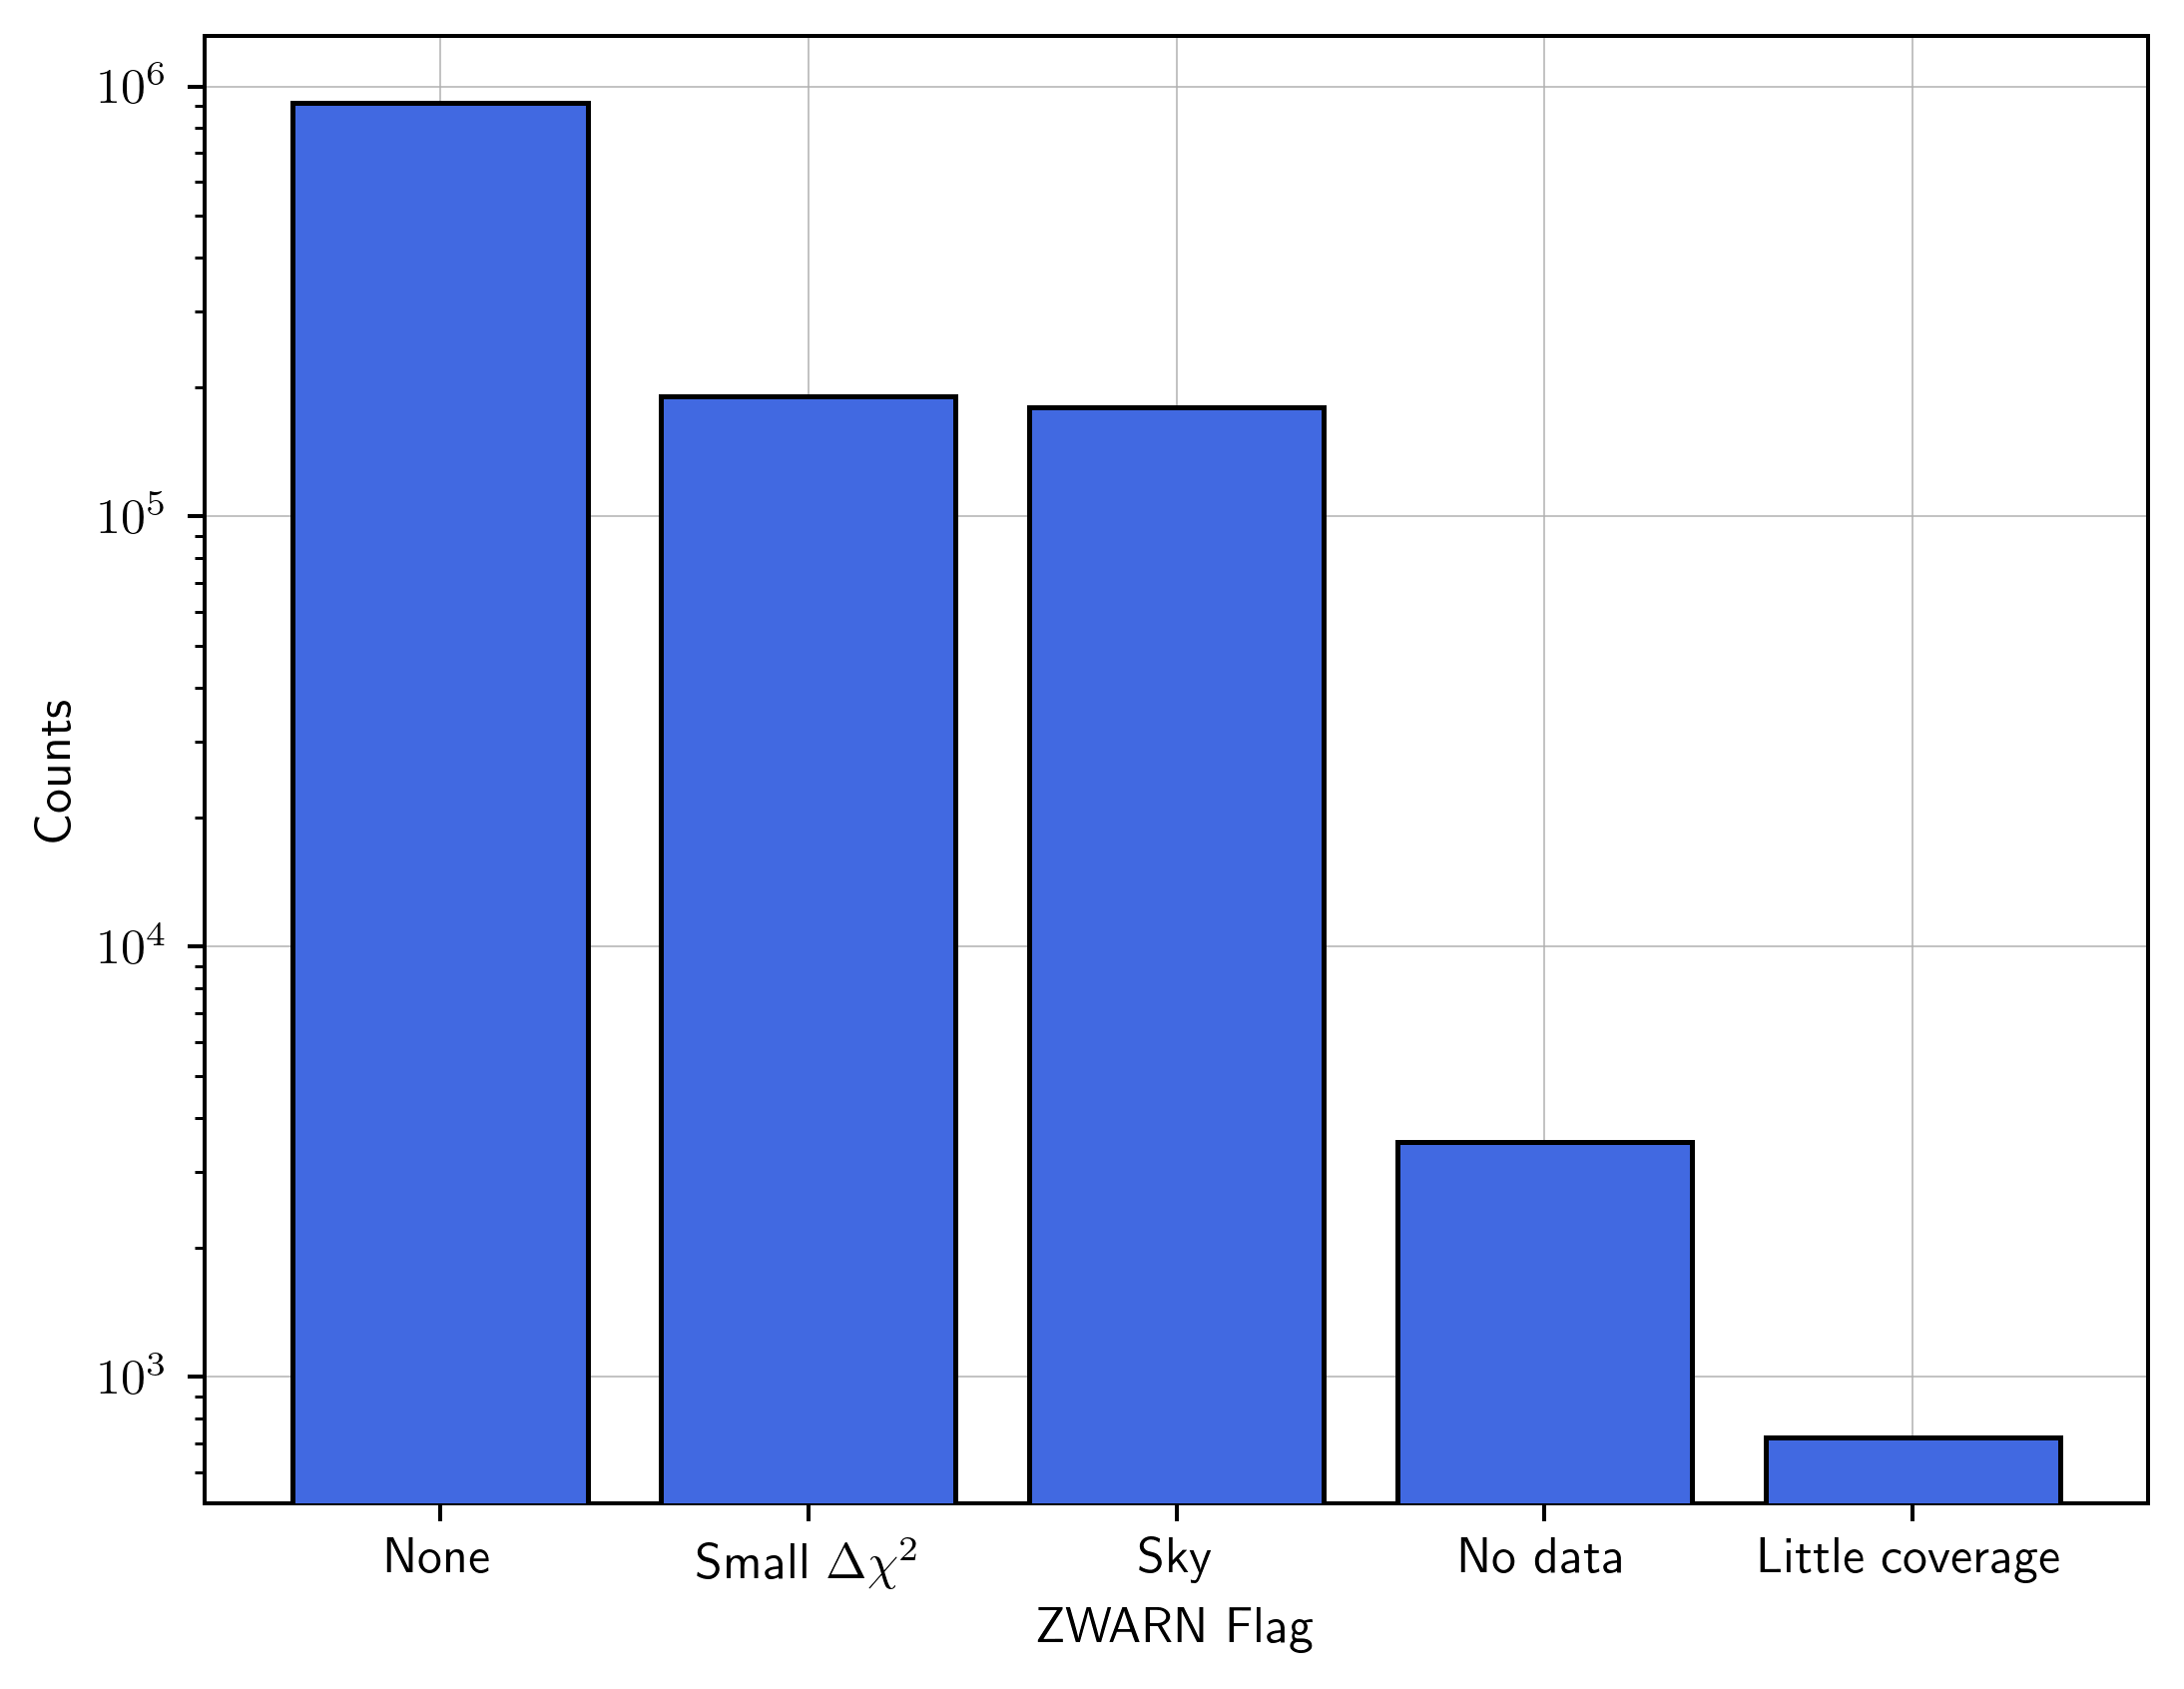

In [ ]:
fig, ax = plt.subplots()

x = np.arange(len(counts))

ax.bar(counts.index, counts.values, color='royalblue', edgecolor='black', zorder=10)
ax.set_xlabel('ZWARN Flag')
ax.set_ylabel('Counts')

labels = [pretty.get(k, k) for k in counts.index]
ax.set_xticks(x, labels=labels, rotation=0, ha='center')

ax.grid(lw=0.3, zorder=0)

plt.tight_layout()
# plt.title('')

plt.yscale('log')
# plt.savefig('flags.png', dpi=360)
plt.show()

In [273]:
base

'/pscratch/sd/v/vtorresg/umap_analysis/sum'

In [276]:
dfff = pd.read_csv(f'/pscratch/sd/v/vtorresg/umap_analysis/data/text_files/20201216_80615.txt')
dfff.head()

,TARGETID,TILEID,FIBER
0,39628483697050350,80615,50
1,39628478441591811,80615,517
2,39628478441589944,80615,524
3,1152921504619431913,80615,832
4,39628483680275969,80615,871


In [279]:
b = '/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/80615/20201216'
tab = Table.read(f'{b}/coadd-1-80615-thru20201216.fits', hdu=1)
tab[tab['TARGETID']==39628478441591811]

TARGETID,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,PLATE_RA,PLATE_DEC,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_X,MEAN_FIBER_Y,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD
,,,,,,deg,deg,,mas / yr,mas / yr,yr,Angstrom,,,,mm,mm,,,,,,,,,mag,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,,arcsec,,,,,mag,mag,mag,mas,,,,,,,,deg,deg,,,s,,,mm,mm,mm,mm,,mm,mm,deg,deg,deg,deg,d,d,d
int64,int16,int32,int64,int32,int32,float64,float64,bytes22,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,bytes8,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,float64,float64,int32,int16,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float64,float32,float64,float32,float64,float64,float64
39628478441591811,1,420,1420,517,0,23.315251444470675,30.0049095371691,DESI J023.3152+30.0049,0.0,0.0,2020.9597,5400.0,9007199254742016,1,TGT,155.97903,-349.00302,3200,0.7737735155765942,7,9010,0231p300,495762,5123,DEV,0.062596306,0.12619828,1.2825335,6.8508306,29.436138,16.817997,996.66754,243.34013,47.202473,2.301086,0.6313562,0.055800878,0.5670957,3.02922,0.055801608,0.56710076,3.029238,0,4.0,0.9146557,0.4935343,-0.23401666,0,--,0.0,0.0,0.0,0.0,S,3200,1,9007199254742016,0,0,0,23.315251444470675,30.0049095371691,80615,4,3600.0,1,1,-0.0035,0.0040620193,-0.00325,0.0077298125,0.74618244,155.9665,-348.996,23.315267767321814,0.027186686,30.004897131787096,0.093724325,59200.06640136,59200.12381137,59200.095110124996


In [280]:
tab

TARGETID,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,PLATE_RA,PLATE_DEC,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_X,MEAN_FIBER_Y,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD
,,,,,,deg,deg,,mas / yr,mas / yr,yr,Angstrom,,,,mm,mm,,,,,,,,,mag,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy^-2,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,,arcsec,,,,,mag,mag,mag,mas,,,,,,,,deg,deg,,,s,,,mm,mm,mm,mm,,mm,mm,deg,deg,deg,deg,d,d,d
int64,int16,int32,int64,int32,int32,float64,float64,bytes22,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,bytes8,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,float64,float64,int32,int16,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float64,float32,float64,float32,float64,float64,float64
39628478445782356,1,417,1417,500,0,23.406523077351494,29.91112577323111,DESI J023.4065+29.9111,0.0,0.0,2020.9597,5400.0,18014398509484032,1,TGT,136.5919,-373.9492,3000,0.41148719767603636,7,9010,0234p300,495763,1364,PSF,0.06275887,0.38925177,0.46135697,0.77385634,1.7063987,0.40568104,1843.9229,670.3073,83.65118,3.490495,0.7683177,0.30250862,0.35854545,0.6014056,0.30250862,0.35854545,0.6014056,0,0.0,0.0,0.0,0.0,0,--,0.0,0.0,0.0,0.0,S,3000,1,18014398509484032,0,0,0,23.406523077351494,29.91112577323111,80615,4,3600.0,1,1,-0.00525,0.005315073,2.1684043e-19,0.0057879183,0.789,136.5825,-373.94626,23.406546779400287,0.013878404,29.91112535412998,0.07690728,59200.06640136,59200.12381137,59200.095110124996
39628478445783071,1,353,1353,501,0,23.44427405573371,30.01195719190046,DESI J023.4442+30.0119,0.0,0.0,2020.9597,5400.0,4096,1,TGT,127.45128,-346.57886,3400,0.650384308985065,1,9010,0234p300,495763,2079,PSF,0.06172012,0.2807904,0.98489034,1.7906952,6.1545324,6.5867333,2401.942,767.6679,102.9491,3.3668582,0.782668,0.21844774,0.76621956,1.3931152,0.21844774,0.76621956,1.3931152,0,0.0,0.0,0.0,0.0,0,--,0.0,0.0,0.0,0.0,S,3400,1,4096,0,0,0,23.44427405573371,30.01195719190046,80615,4,3600.0,1,1,-0.00275,0.00295804,0.0005,0.006244998,0.789,127.438,-346.5725,23.444286506360527,0.015784739,30.011958871543758,0.08380346,59200.06640136,59200.12381137,59200.095110124996
616089230749205387,1,377,1377,502,0,23.342290769650337,30.06350770599551,DESI J023.3422+30.0635,0.0,0.0,0.0,5400.0,4294967296,4,SKY,149.48909,-333.19885,-1,0.9259805968784437,63,9010,0234p300,495763,907,--,0.061780404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.021135673,-0.03292114,-0.0023346904,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,--,0.0,0.0,0.0,0.0,--,-1,-1,4294967296,4294967296,0,0,23.342290769650337,30.06350770599551,80615,4,3600.0,1,1,-0.003,0.004636809,0.00125,0.0072629196,0.79267186,149.476,-333.1945,23.342304218898335,0.04818199,30.06351217522878,0.09623626,59200.06640136,59200.12381137,59200.095110124996
39628478445783239,1,394,1394,503,0,23.45367240788775,29.91356107008708,DESI J023.4536+29.9135,11.694247,-5.2286525,2015.5,5400.0,42949673511,3,TGT,126.13426,

In [327]:
tabb = Table.read('/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/25172/20230312/redrock-0-25172-thru20230312.fits', hdu=1)

In [328]:
tabb

TARGETID,Z,ZERR,ZWARN,CHI2,COEFF,FITMETHOD,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2
int64,float64,float64,int64,float64,float64[10],bytes4,int64,bytes6,bytes20,int64,float64
39628186840990748,0.413642481262469,4.1989650125808596e-05,0,7805.63963599503,7.349562014889517 .. -23.201323373115553,PCA,7887,GALAXY,--,10,133.47269819676876
39628186840993031,0.10430763508350778,9.592801889909872e-06,0,7688.771037146449,444.49847414816315 .. 3.0195434686850717,PCA,7901,GALAXY,--,10,558.8316329270601
39628192629129300,0.10568429703156001,3.378960351064002e-05,0,8584.118429457769,3140.9731227717925 .. 137.76911191065753,PCA,7907,GALAXY,--,10,1228.2436024378985
39628192629131759,0.10384772341582879,1.4425521079123721e-05,0,7567.772501572967,505.1539857863094 .. 2.006892757109579,PCA,7885,GALAXY,--,10,265.66581209003925
39628192629133263,0.3561717048407803,8.06684112520945e-05,0,7440.499949853867,318.6970208480036 .. -14.876936359286821,PCA,7859,GALAXY,--,10,115.00461030006409
39628192624939341,7.530338695810714e-05,2.8310025898779315e-05,0,7983.9726959388645,1560.3354075669922 .. 0.0,PCA,7887,STAR,K,5,239.5465094916217
39628192629130477,-4.483575309410759e-05,5.686822487907266e-06,0,8806.729963846425,2847.2674717845084 .. 0.0,PCA,7888,STAR,K,5,2449.1995425746645
39628192629130778,6.045833726045555e-05,5.09847334206297e-06,0,11424.347873823746,3353.466541390463 .. 0.0,PCA,7877,STAR,K,5,2409.3416747648625
39628186840991350,0.21675596579324982,1.6875726562507705e-05,0,7550.883964627981,467.2842644577928 .. 2.953886070486665,PCA,7877,GALAXY,--,10,329.52304831147194


In [ ]:
files = [
    '/pscratch/sd/v/vtorresg/umap_analysis/data/sep_bands/b/processed/umap/umap_20231214_26024.npz',
    '/pscratch/sd/v/vtorresg/umap_analysis/data/sep_bands/r/processed/umap/umap_20231214_26024.npz',
    '/pscratch/sd/v/vtorresg/umap_analysis/data/sep_bands/z/processed/umap/umap_20231214_26024.npz',
]

In [ ]:
target_id = 39633460310051122
same_limits = True
point_size = 10
alpha_all = 0.10

In [ ]:
def parse_title(fname: str) -> str:
    m = re.search(r'umap_(\d{8})_(\d+)\.npz$', Path(fname).name)
    if m:
        ymd, tile = m.groups()
        return f'Tile {tile} - Night {ymd}'
    return Path(fname).name

def load_umap(npz_path: str):
    data = np.load(npz_path, allow_pickle=True)
    arr = data['embedding']
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError()

    mask = data['outlier_mask'] if 'outlier_mask' in data.files else np.zeros(len(arr), dtype=bool)
    ids  = data['ids'] if 'ids' in data.files else np.array([], dtype=np.int64)
    return arr, mask, ids

In [23]:
all_x, all_y = [], []
preloaded = []

for f in files:
    arr, mask, ids = load_umap(f)
    title = parse_title(f)
    preloaded.append((arr, mask, ids, title))
    if same_limits:
        all_x.append(arr[:, 0])
        all_y.append(arr[:, 1])

if same_limits:
    all_x = np.concatenate(all_x) if all_x else np.array([0.0])
    all_y = np.concatenate(all_y) if all_y else np.array([0.0])
    pad_x = 0.03 * (all_x.max() - all_x.min() + 1e-9)
    pad_y = 0.03 * (all_y.max() - all_y.min() + 1e-9)
    xlims = (all_x.min() - pad_x, all_x.max() + pad_x)
    ylims = (all_y.min() - pad_y, all_y.max() + pad_y)
else:
    xlims = ylims = None


0
1
2


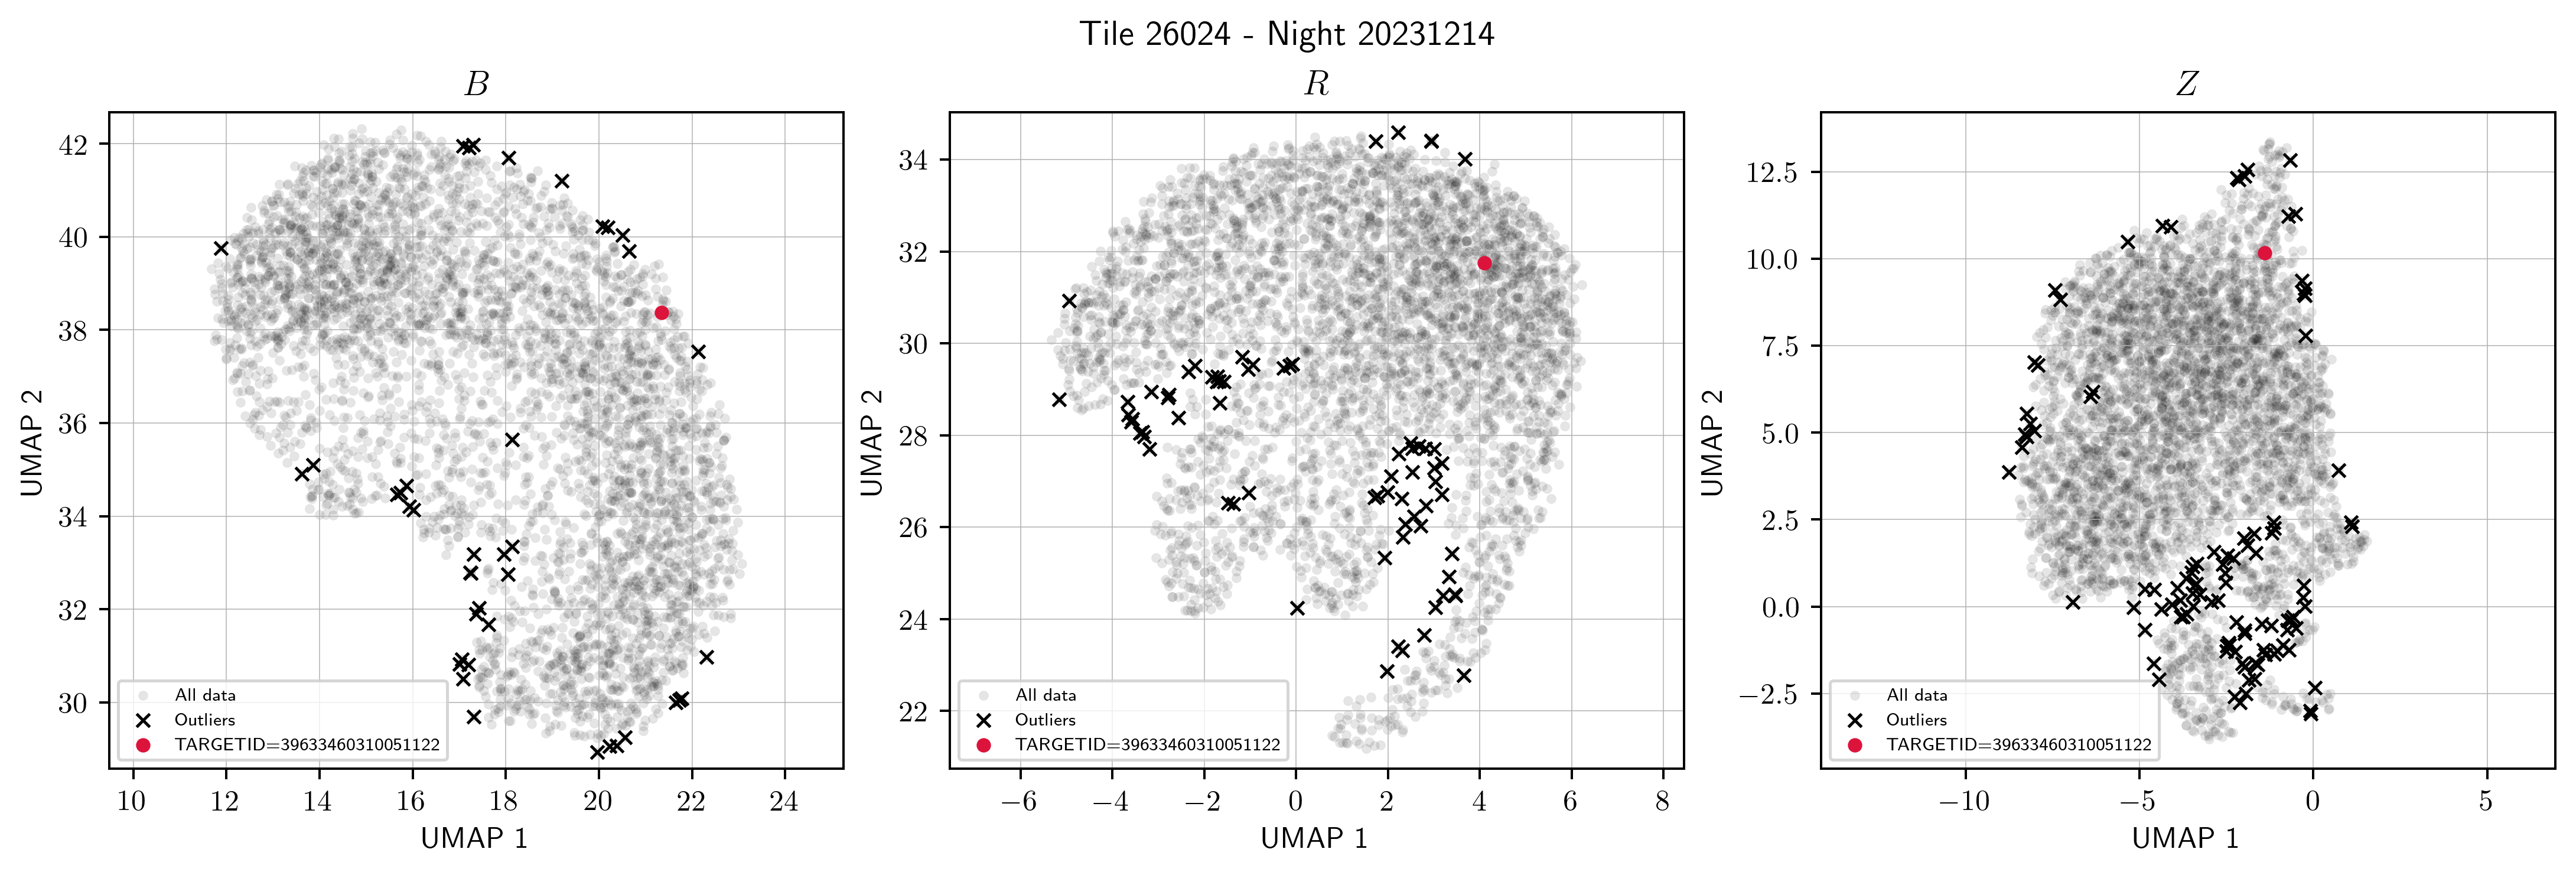

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), constrained_layout=True)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for i, (ax, (arr, mask, ids, title)) in enumerate(zip(axes, preloaded)):
    ax.grid(linewidth=0.3, zorder=-1)

    ax.scatter(
        arr[:, 0], arr[:, 1],
        s=point_size, zorder=1, color='black', linewidths=0.1,
        edgecolor='black', label='All data', alpha=alpha_all
    )

    if mask.any():
        outliers = arr[mask]
        ax.scatter(
            outliers[:, 0], outliers[:, 1],
            zorder=10, color='black', s=point_size+10,
            label='Outliers', marker='x', linewidths=1
        )

    target_present = False
    if ids.size > 0:
        target_mask = (ids == target_id)
        if target_mask.any():
            target_coords = arr[target_mask]
            ax.scatter(
                target_coords[:, 0], target_coords[:, 1],
                zorder=20, color='crimson', s=point_size+5, marker='o',
                label=f'TARGETID={target_id}'
            )
            target_present = True

    print(i)
    if i==0:
        ax.set_title(r'$B$')
    elif i==1:
        ax.set_title(r'$R$')
    elif i==2:
        ax.set_title(r'$Z$')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_aspect('equal', adjustable='datalim')
    # if xlims and ylims:
    #     ax.set_xlim(*xlims)
    #     ax.set_ylim(*ylims)
    ax.legend(loc='lower left', fontsize=6)

plt.suptitle(title)
# plt.savefig('bands_26024.png')
plt.show()